# STEP 1 : BUSINESS UNDERSTANDING

##### 1.Problem Statement

    A bank wants to decide whether a loan should be approved or not.
    We have past customer data, and we need to build a model that predicts Loan_Status (Y/N).

##### 2.Business Goal

    Use customer details (income, loan amount, credit history, etc.)
    to automatically predict loan approval.

##### 3.Why this project is important

    Helps bank reduce time
    
    Makes decisions consistent
    
    Reduces risk
    
    Improves customer experience

##### 4.ML Problem Type

    This is a Supervised Classification Problem
    because the target variable (Loan_Status) has labels: Y / N

##### 5.Impact of wrong predictions:

    Approving a risky customer → Bank loses money
    
    Rejecting a good customer → Bank loses business
    
    So the model must be accurate and reliable.

-----------------------------------------------------------------------------------------------------------

# STEP 2: COLLECT AND LOAD THE DATASET

##### Load Data

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ADMIN\Downloads\train_u6lujuX_CVtuZ9i.csv")

------------------------------------------------------------------------------------------------------------

# STEP 3 : DATA UNDERSTANDING

In [2]:
# Check Rows & Columns
df.shape

(614, 13)

In [3]:
# To see the first few rows and get a quick idea of the data
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


I checked the first few rows and understood that the dataset contains applicant details, income-related information, property information, and loan approval status.

In [4]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

The dataset has features like Gender, Married, Dependents, Income, Property area, Loan amount, etc. These columns describe the applicant and their financial background.

In [5]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Categorical columns: Gender, Married, Dependents, Education, Self_Employed, Property_Area, Loan_Status.

Numerical columns: ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term,Credit_History



In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


-------------------------------------------------------------------------------------------------------------------

# STEP 4 : DATA CLEANING

In [7]:
# Check Missing Values
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

I checked missing values in all columns.Gender,Married,Dependents,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History have missing values.                       

In [8]:
missing_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed',
                'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

# Convert Loan_Status to numeric if not already
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

for col in missing_cols:
    print(f"\n====== Checking Missing Impact for: {col} ======\n")
    
    # Create missing indicator column
    df[col + '_missing'] = df[col].isnull()
    
    # Compare approval rate
    print(df.groupby(col + '_missing')['Loan_Status'].mean())



====== Checking Missing Impact for: Gender ======

Gender_missing
False    0.688852
True     0.615385
Name: Loan_Status, dtype: float64

====== Checking Missing Impact for: Married ======

Married_missing
False    0.685761
True     1.000000
Name: Loan_Status, dtype: float64

====== Checking Missing Impact for: Dependents ======

Dependents_missing
False    0.689482
True     0.600000
Name: Loan_Status, dtype: float64

====== Checking Missing Impact for: Self_Employed ======

Self_Employed_missing
False    0.685567
True     0.718750
Name: Loan_Status, dtype: float64

====== Checking Missing Impact for: LoanAmount ======

LoanAmount_missing
False    0.694257
True     0.500000
Name: Loan_Status, dtype: float64

====== Checking Missing Impact for: Loan_Amount_Term ======

Loan_Amount_Term_missing
False    0.690000
True     0.571429
Name: Loan_Status, dtype: float64

====== Checking Missing Impact for: Credit_History ======

Credit_History_missing
False    0.682624
True     0.740000
Name: L

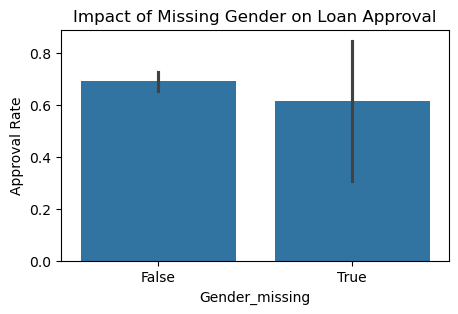

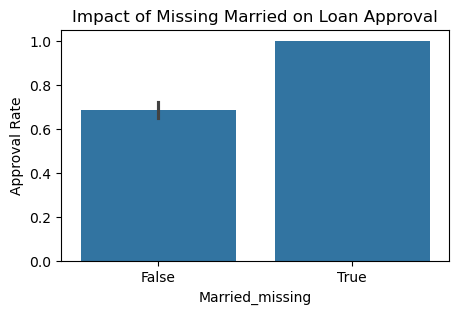

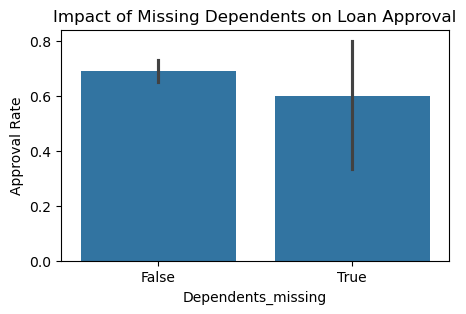

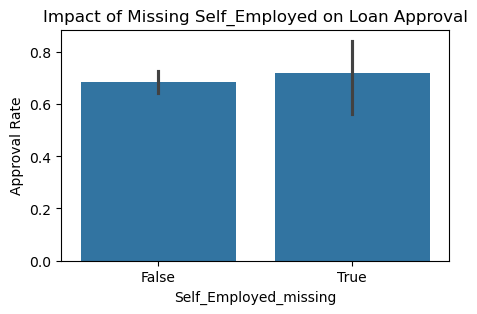

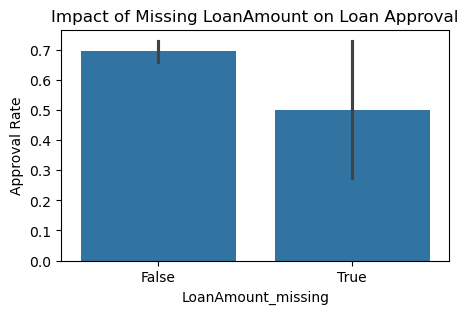

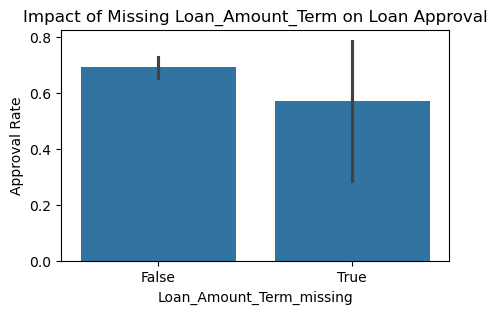

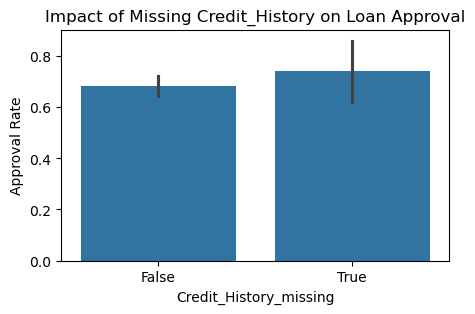

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in missing_cols:
    # create missing indicator
    df[col + '_missing'] = df[col].isnull()
    
    plt.figure(figsize=(5,3))
    sns.barplot(
        x = col + '_missing',
        y = 'Loan_Status',
        data = df
    )
    plt.title(f"Impact of Missing {col} on Loan Approval")
    plt.ylabel('Approval Rate')
    plt.xlabel(f'{col}_missing')
    plt.show()

“I checked whether the missing values for each feature were related to loan approval. LoanAmount and Loan_Amount_Term showed strong negative impacts when missing, indicating these features are important for model learning. Gender, Dependents, and Credit_History showed small differences, meaning missingness has weak relationships. Self_Employed missingness had almost no effect. Missing Married showed 100% approval, but this is likely due to very few missing samples and does not represent a real pattern.”

In [10]:
# Categorical columns → mode
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']

train_modes = {}

for col in cat_cols:
    train_modes[col] = df[col].mode()[0]
    df[col] = df[col].fillna(train_modes[col])
    

In [11]:
# Numerical columns
# Create missing indicators
df['LoanAmount_missing_flag'] = df['LoanAmount'].isnull().astype(int)
df['Loan_Amount_Term_missing_flag'] = df['Loan_Amount_Term'].isnull().astype(int)

# Now fill missing values (median)
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())


“LoanAmount and Loan_Amount_Term had strong missing impact, meaning that the missingness itself contains useful information. Therefore, I created missing indicator columns before imputing the values. This allows the model to learn both the cleaned value and the risk associated with missing entries.”

In [12]:
# To final Check of Missing Values
df.isnull().sum()

Loan_ID                          0
Gender                           0
Married                          0
Dependents                       0
Education                        0
Self_Employed                    0
ApplicantIncome                  0
CoapplicantIncome                0
LoanAmount                       0
Loan_Amount_Term                 0
Credit_History                   0
Property_Area                    0
Loan_Status                      0
Gender_missing                   0
Married_missing                  0
Dependents_missing               0
Self_Employed_missing            0
LoanAmount_missing               0
Loan_Amount_Term_missing         0
Credit_History_missing           0
LoanAmount_missing_flag          0
Loan_Amount_Term_missing_flag    0
dtype: int64

In [13]:
# Save values from TRAIN data To Apply SAME values to TEST data:
LoanAmount_median = df['LoanAmount'].median()
Loan_Amount_Term_median = df['Loan_Amount_Term'].median()

In [14]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,...,Loan_Status,Gender_missing,Married_missing,Dependents_missing,Self_Employed_missing,LoanAmount_missing,Loan_Amount_Term_missing,Credit_History_missing,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,...,1,False,False,False,False,True,False,False,1,0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,...,0,False,False,False,False,False,False,False,0,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,...,1,False,False,False,False,False,False,False,0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,...,1,False,False,False,False,False,False,False,0,0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,...,1,False,False,False,False,False,False,False,0,0


In [15]:
cols_to_drop = [col + '_missing' for col in [
    'Gender','Married','Dependents','Self_Employed','LoanAmount','Loan_Amount_Term','Credit_History'
]]

df.drop(columns=cols_to_drop, inplace=True)


In [16]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1,1,0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0,0,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1,0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1,0,0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1,0,0


In [17]:
# Check for Duplicates
df.duplicated().sum()

np.int64(0)

“No duplicate rows were found.”

In [18]:
# To check Wrong Data Types
df.dtypes

Loan_ID                           object
Gender                            object
Married                           object
Dependents                        object
Education                         object
Self_Employed                     object
ApplicantIncome                    int64
CoapplicantIncome                float64
LoanAmount                       float64
Loan_Amount_Term                 float64
Credit_History                   float64
Property_Area                     object
Loan_Status                        int64
LoanAmount_missing_flag            int64
Loan_Amount_Term_missing_flag      int64
dtype: object

In [19]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1,1,0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0,0,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1,0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1,0,0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1,0,0


In [20]:
df['Dependents'].value_counts()

Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

In [21]:
df.dtypes

Loan_ID                           object
Gender                            object
Married                           object
Dependents                        object
Education                         object
Self_Employed                     object
ApplicantIncome                    int64
CoapplicantIncome                float64
LoanAmount                       float64
Loan_Amount_Term                 float64
Credit_History                   float64
Property_Area                     object
Loan_Status                        int64
LoanAmount_missing_flag            int64
Loan_Amount_Term_missing_flag      int64
dtype: object

In [22]:
# Step 1: Replace '3+' with 3
df['Dependents'] = df['Dependents'].replace('3+', 3)

# Step 2: Convert the column to integer
df['Dependents'] = df['Dependents'].astype(int)

# Step 3: Check the result
df['Dependents'].dtype  # Should now show int64
df['Dependents'].value_counts()  # Check all values


Dependents
0    360
1    102
2    101
3     51
Name: count, dtype: int64

“The Dependents column contained string values including ‘3+’. I replaced ‘3+’ with 3 and converted the column to integer. This allows the column to be treated as numeric, which is important for exploratory data analysis, correlation analysis, and modeling.”

In [23]:
df['Credit_History'].value_counts()

Credit_History
1.0    525
0.0     89
Name: count, dtype: int64

In [24]:
# Convert to integer
df['Credit_History'] = df['Credit_History'].astype(int)

In [25]:
df.dtypes

Loan_ID                           object
Gender                            object
Married                           object
Dependents                         int64
Education                         object
Self_Employed                     object
ApplicantIncome                    int64
CoapplicantIncome                float64
LoanAmount                       float64
Loan_Amount_Term                 float64
Credit_History                     int64
Property_Area                     object
Loan_Status                        int64
LoanAmount_missing_flag            int64
Loan_Amount_Term_missing_flag      int64
dtype: object

In [26]:
# To check wrong values
# for Numerical columns
df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.744300,5403.459283,1621.245798,145.752443,342.410423,0.855049,0.687296,0.035831,0.022801
std,1.009623,6109.041673,2926.248369,84.107233,64.428629,0.352339,0.463973,0.186019,0.149391
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000,0.000000,0.000000
50%,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000,0.000000,0.000000
75%,1.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,1.000000,0.000000,0.000000
max,3.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,1.000000,1.000000,1.000000


“I used df.describe() to check if numerical columns contain impossible values.
ApplicantIncome, LoanAmount, and Loan_Amount_Term should never be zero, so I checked whether these columns contained zero values. CoapplicantIncome can be zero because sometimes only one person applies for the loan.”

In [27]:
# for Categorical columns
cat_cols = ['Gender','Married','Dependents','Education','Self_Employed','Credit_History','Property_Area']

for col in cat_cols:
    print(f"{col} unique values: {df[col].unique()}")


Gender unique values: ['Male' 'Female']
Married unique values: ['No' 'Yes']
Dependents unique values: [0 1 2 3]
Education unique values: ['Graduate' 'Not Graduate']
Self_Employed unique values: ['No' 'Yes']
Credit_History unique values: [1 0]
Property_Area unique values: ['Urban' 'Rural' 'Semiurban']


“I checked all categorical columns to ensure they contain only valid categories.
I printed the unique values of each feature to detect any invalid, unknown, or unexpected categories.”

Irrelevant Columns :
    After reviewing all the columns, I found that Loan_ID is an identifier and does not contain any predictive information.
    I marked it for removal during feature selection.

Data Leakage Check :
    I checked the dataset for any columns that could leak future information or directly reveal the loan decision.
    No data leakage columns were found in this dataset.

In [28]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1,Urban,1,1,0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,0,0,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,1,0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,1,0,0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,1,0,0


------------------------------------------------------------------------------------------------------------------

# STEP 5: EDA 

### Univariate Analysis

In [29]:
# Numerical Columns:
df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.744300,5403.459283,1621.245798,145.752443,342.410423,0.855049,0.687296,0.035831,0.022801
std,1.009623,6109.041673,2926.248369,84.107233,64.428629,0.352339,0.463973,0.186019,0.149391
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000,0.000000,0.000000
50%,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000,0.000000,0.000000
75%,1.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,1.000000,0.000000,0.000000
max,3.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,1.000000,1.000000,1.000000


In [30]:
# Categorical Columns:
cat_cols = ['Gender','Married','Dependents','Education','Self_Employed','Credit_History','Loan_Amount_Term','Property_Area']

for col in cat_cols:
    print(df[col].value_counts())


Gender
Male      502
Female    112
Name: count, dtype: int64
Married
Yes    401
No     213
Name: count, dtype: int64
Dependents
0    360
1    102
2    101
3     51
Name: count, dtype: int64
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64
Self_Employed
No     532
Yes     82
Name: count, dtype: int64
Credit_History
1    525
0     89
Name: count, dtype: int64
Loan_Amount_Term
360.0    526
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64


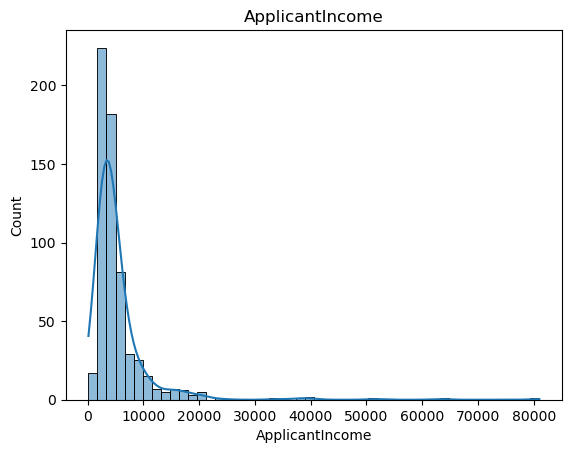

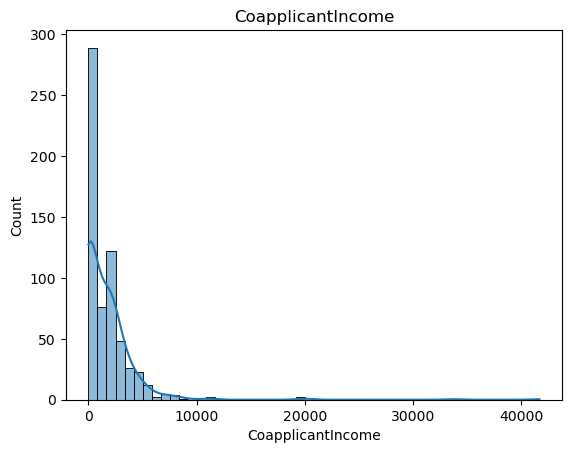

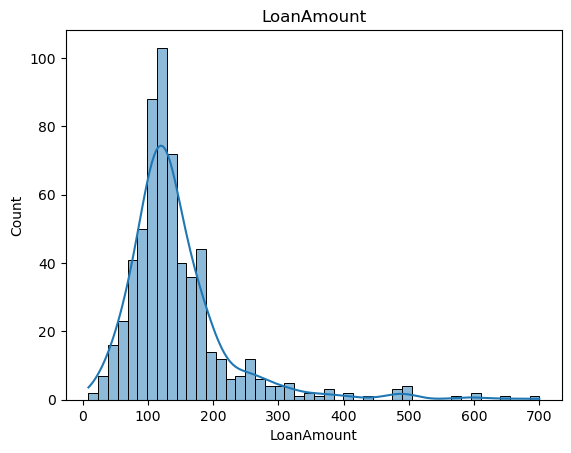

In [31]:
# Numerical Columns:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount']

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()


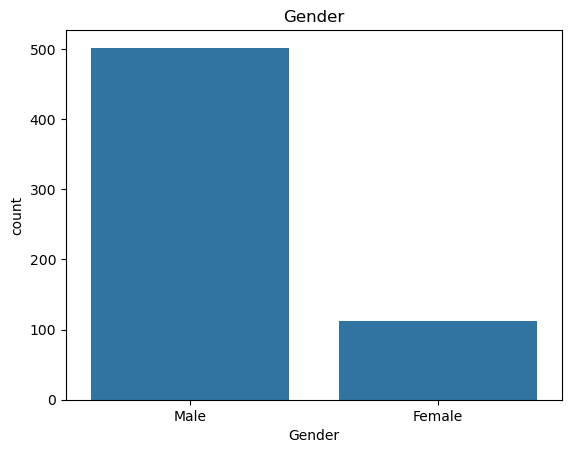

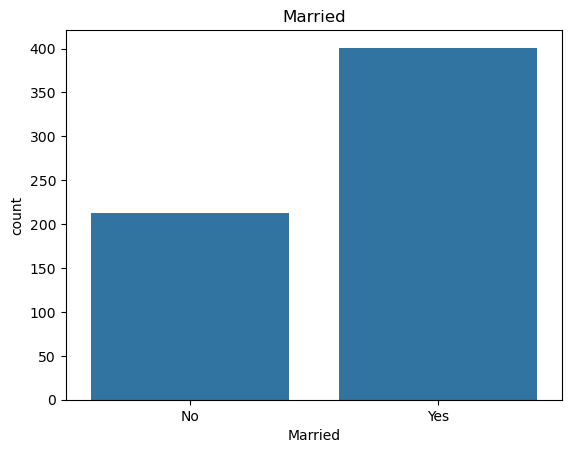

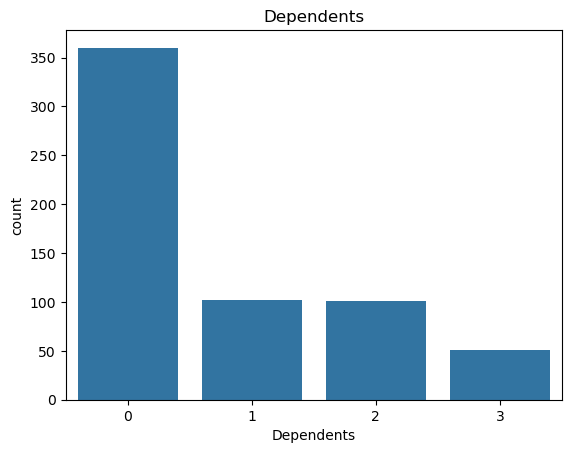

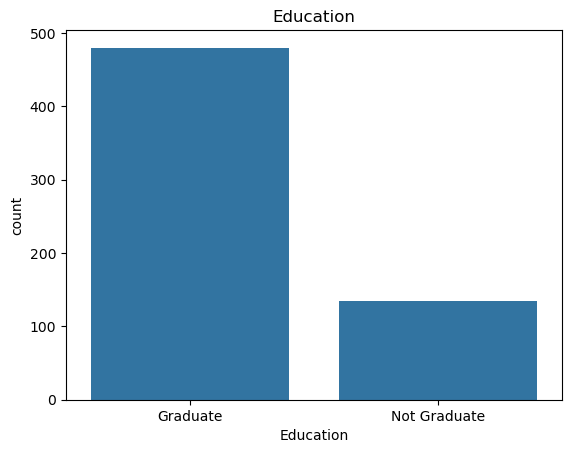

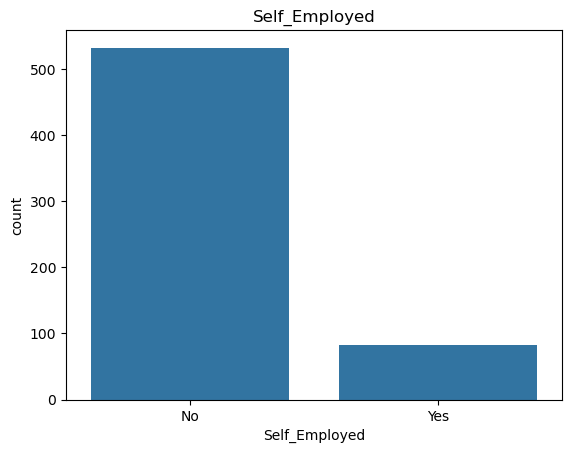

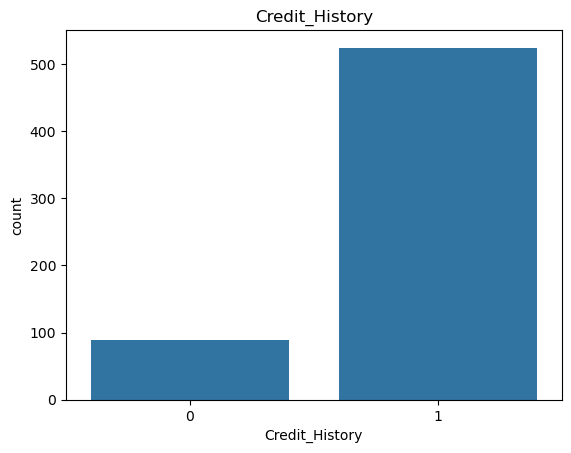

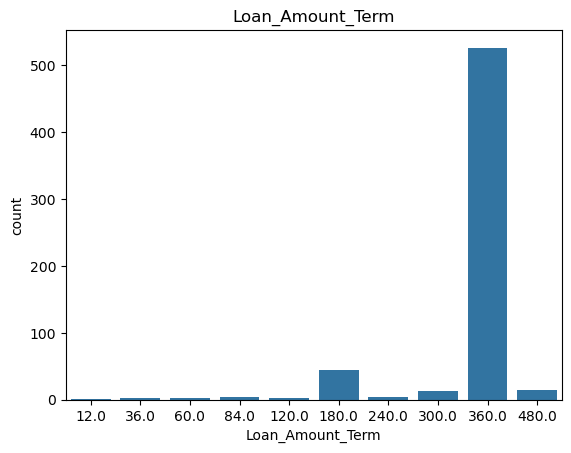

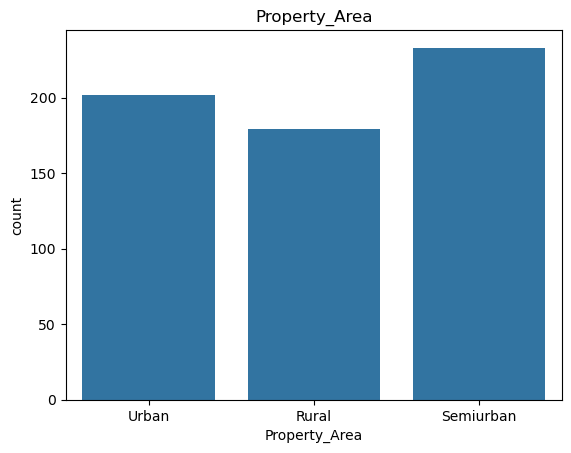

In [32]:
# Categorical Columns:
for col in cat_cols:
    sns.countplot(x=df[col])
    plt.title(col)
    plt.show()


Univariate EDA Summary : 

During Univariate EDA, I analyzed each column individually.

✔️ Categorical Features

I checked the frequency of each category and observed:

Most applicants are Male

Most are Married

Majority have 0 Dependents

Most are Graduates

Most are Not Self-Employed

Majority have Credit_History = 1

Loan_Amount_Term = 360 months is the most common loan duration
(I treated Loan_Amount_Term like a categorical column.)

✔️ Numerical Features

ApplicantIncome, CoapplicantIncome, and LoanAmount are right-skewed

These columns also show outliers

Since these features are important for prediction, transformation/outlier handling will be needed

------------------------------------------------------------------------------------------------------------

Important insights:

A. Skewed numerical features → may need transformation

Because:ApplicantIncome,CoapplicantIncome and LoanAmount are skewed, applying log transformation or outlier handling may improve model performance.

B. Credit_History is a very important feature

People with credit history are more common.

This feature might strongly affect loan approval prediction.

C. Loan_Amount_Term has one dominating category

360 months is the most common term.

So:

The model may not learn much from rare term values.

We may consider grouping rare values.

D. Categorical imbalance

Features like:

Gender

Married

Self_Employed

are imbalanced but still useful.




### Bivariate Analysis

In [33]:
# Categorical features relation with target
for col in cat_cols:
    print(f"Approval Rate by {col}:")
    print(df.groupby(col)['Loan_Status'].mean())
    print("-"*40)


Approval Rate by Gender:
Gender
Female    0.669643
Male      0.691235
Name: Loan_Status, dtype: float64
----------------------------------------
Approval Rate by Married:
Married
No     0.629108
Yes    0.718204
Name: Loan_Status, dtype: float64
----------------------------------------
Approval Rate by Dependents:
Dependents
0    0.686111
1    0.647059
2    0.752475
3    0.647059
Name: Loan_Status, dtype: float64
----------------------------------------
Approval Rate by Education:
Education
Graduate        0.708333
Not Graduate    0.611940
Name: Loan_Status, dtype: float64
----------------------------------------
Approval Rate by Self_Employed:
Self_Employed
No     0.687970
Yes    0.682927
Name: Loan_Status, dtype: float64
----------------------------------------
Approval Rate by Credit_History:
Credit_History
0    0.078652
1    0.790476
Name: Loan_Status, dtype: float64
----------------------------------------
Approval Rate by Loan_Amount_Term:
Loan_Amount_Term
12.0     1.000000
36.0  

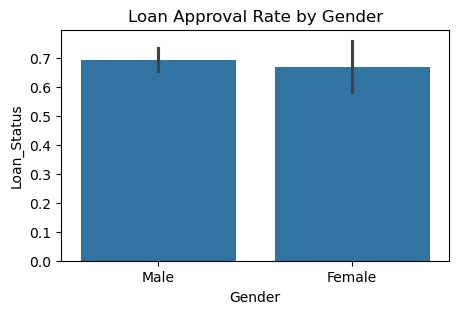

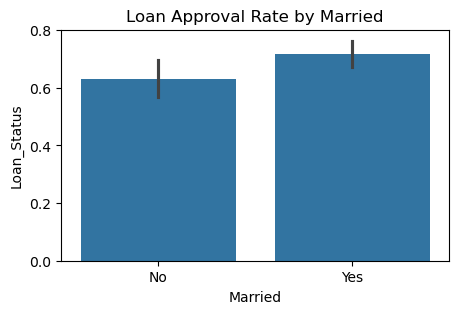

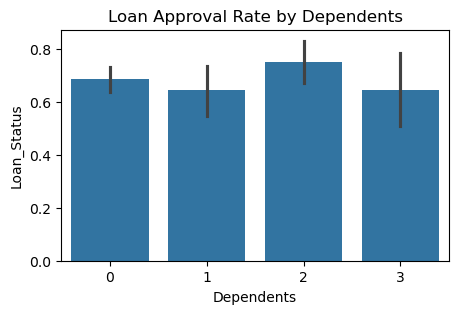

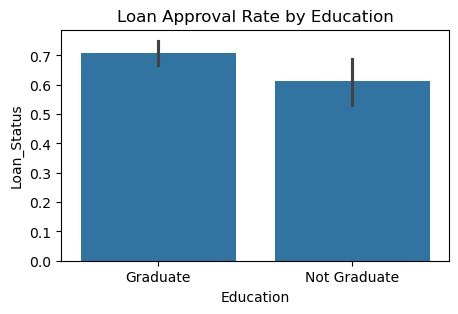

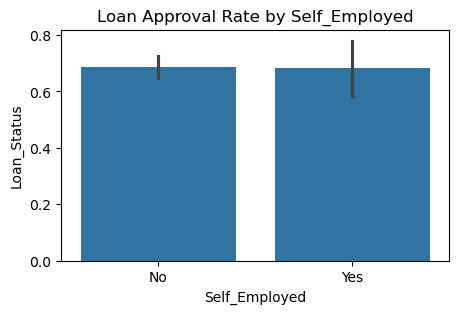

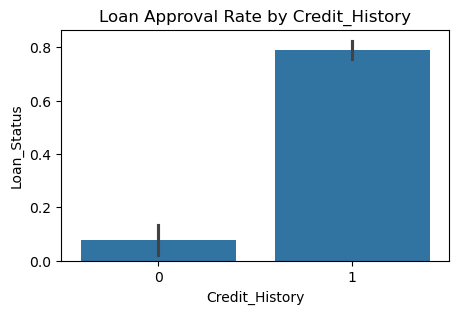

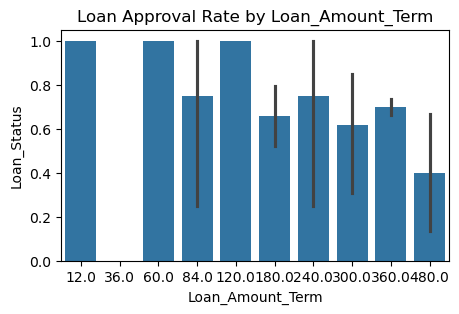

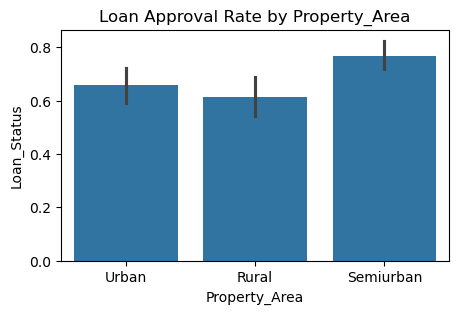

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.barplot(x=col, y="Loan_Status", data=df)
    plt.title(f"Loan Approval Rate by {col}")
    plt.show()


In [35]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1,Urban,1,1,0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,0,0,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,1,0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,1,0,0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,1,0,0


In [36]:
# Numerical features relation with target
for col in num_cols:
    means = df.groupby('Loan_Status')[col].mean()
    
    diff = abs(means[1] - means[0])
    avg = df[col].mean()
    
    percent_diff = (diff / avg) * 100
    
    print(f"{col} → Difference % = {percent_diff:.2f}%")


ApplicantIncome → Difference % = 1.15%
CoapplicantIncome → Difference % = 23.02%
LoanAmount → Difference % = 4.13%


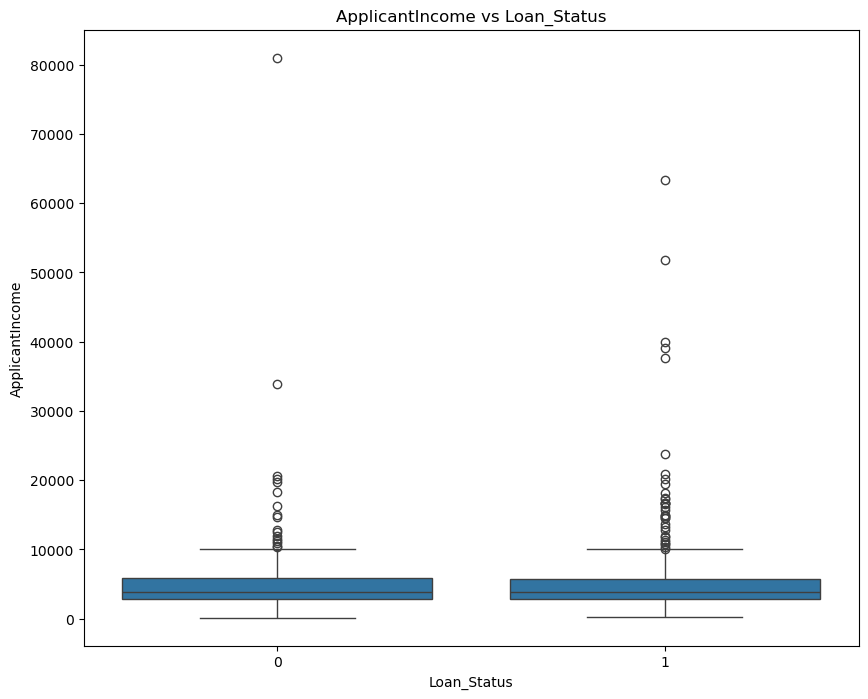

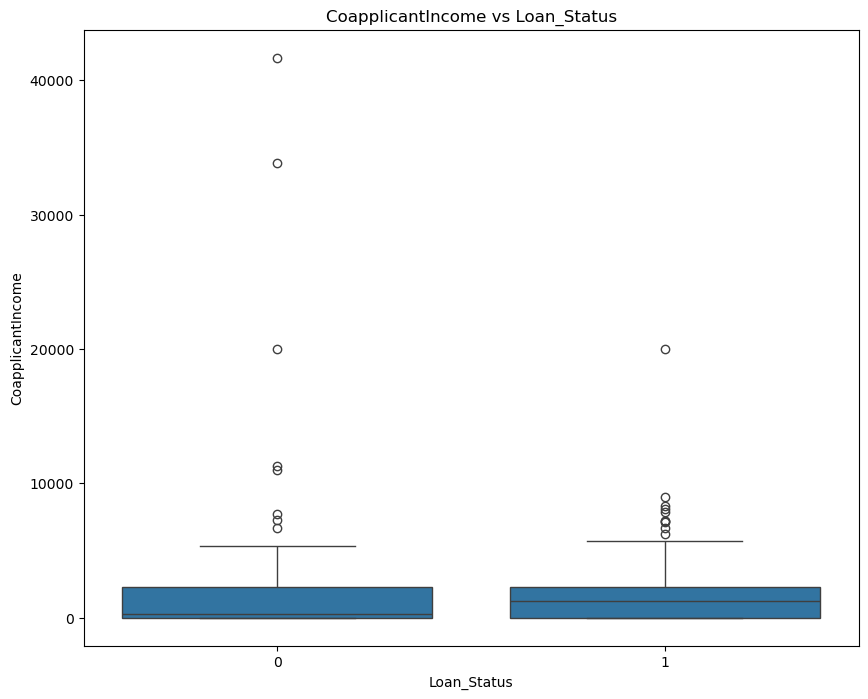

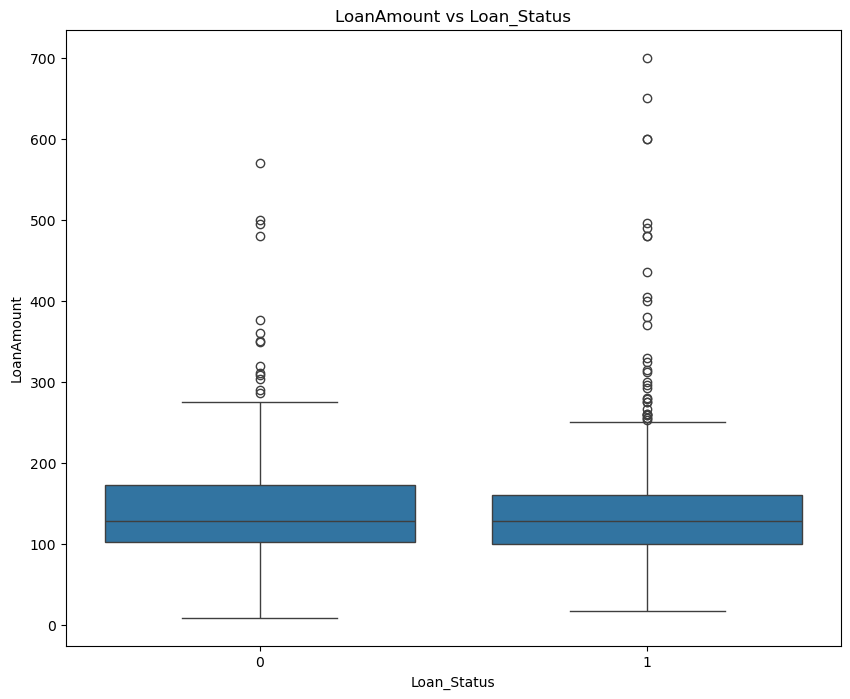

In [37]:
for col in num_cols: 
    plt.figure(figsize=(10,8)) 
    sns.boxplot(x='Loan_Status', y=col, data=df) 
    plt.title(f'{col} vs Loan_Status') 
    plt.show()

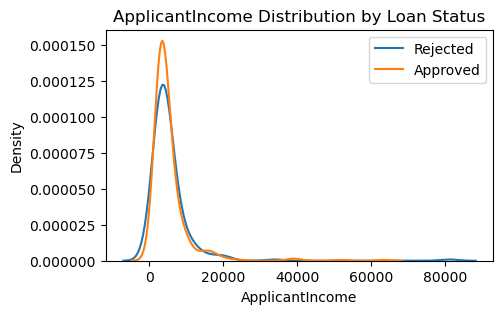

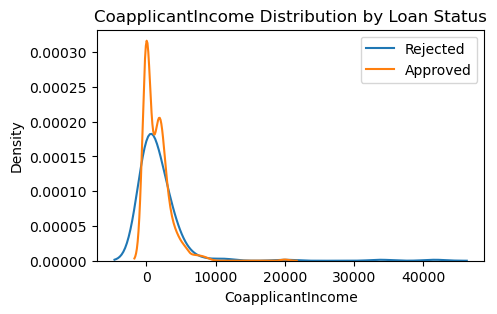

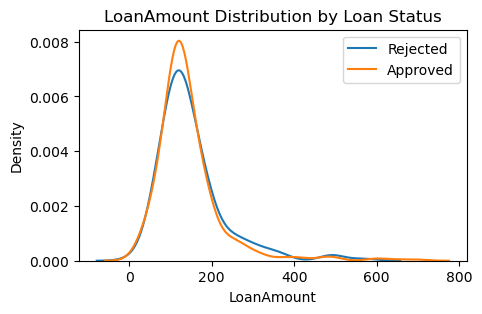

In [38]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.kdeplot(data=df[df['Loan_Status']==0], x=col, label='Rejected')
    sns.kdeplot(data=df[df['Loan_Status']==1], x=col, label='Approved')
    plt.title(f"{col} Distribution by Loan Status")
    plt.legend()
    plt.show()



===== ApplicantIncome vs Loan_Status =====


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24236\1576902568.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(col + '_bins')['Loan_Status'].mean().reset_index()


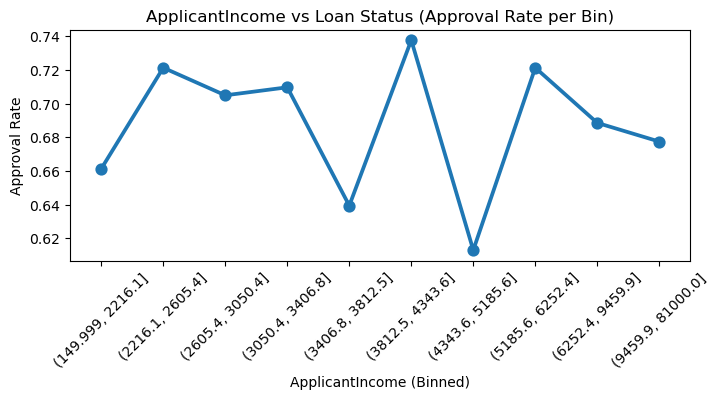


===== CoapplicantIncome vs Loan_Status =====


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24236\1576902568.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(col + '_bins')['Loan_Status'].mean().reset_index()


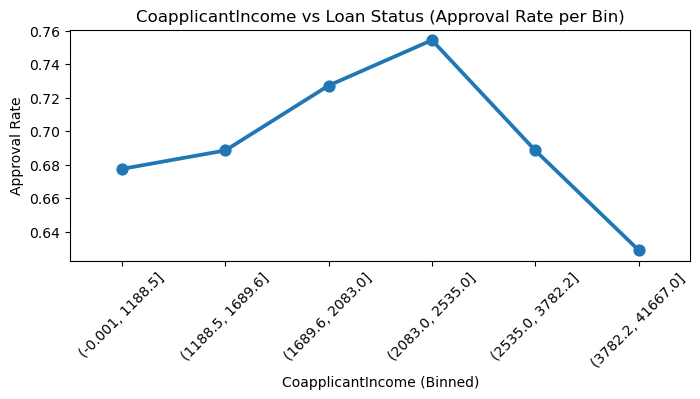


===== LoanAmount vs Loan_Status =====


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24236\1576902568.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(col + '_bins')['Loan_Status'].mean().reset_index()


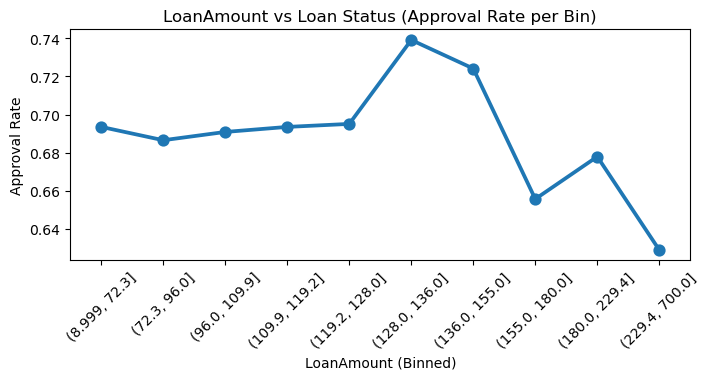

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for col in num_cols:
    print(f"\n===== {col} vs Loan_Status =====")

    # 1. Create bins (10 quantile bins)
    df[col + '_bins'] = pd.qcut(df[col], q=10, duplicates='drop')

    # 2. Calculate approval rate per bin
    stats = df.groupby(col + '_bins')['Loan_Status'].mean().reset_index()

    # 3. Plot
    plt.figure(figsize=(8,3))
    sns.pointplot(data=stats, x=col + '_bins', y='Loan_Status')
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Loan Status (Approval Rate per Bin)")
    plt.ylabel("Approval Rate")
    plt.xlabel(f"{col} (Binned)")
    plt.show()


Bivariate Analysis (Feature vs Target)

I analyzed how each feature is related to the target (Loan_Status).
    
For categorical features, I used approval rate using groupby.
    
For numerical features, I used binning + line plot.
(Boxplot/KDE were used only for distribution understanding.)

Summary of Relationships:

    1.Strong Relationship: These features show clear and large differences in approval rates.
        
        Credit_History → very high approval for credit = 1
        
        Property_Area → Semiurban clearly higher

    2.Moderate Relationship: Some noticeable difference in approval rates.

        Married
        
        Education

    3.Weak / Noisy Relationship: Approval rates are similar across categories or show zig-zag patterns.

        Gender
        
        Self_Employed
        
        Dependents
        
        Loan_Amount_Term
        
        ApplicantIncome (after binning → no clear trend)
        
        LoanAmount (after binning → no clear trend)
        
        CoapplicantIncome (slightly better but still weak)

---------------------------------------------------------------------------------------------------------

### Multivariate Analysis

##### REDUNDANCY CHECK

Features Checked for Redundancy:

We evaluated redundancy only for feature pairs that logically describe the same information:

ApplicantIncome & CoapplicantIncome

Both represent income-related information.

→ Correlation was low → No redundancy found.

LoanAmount & Loan_Amount_Term

Both describe loan details (amount and duration).

→ Weak dependency → No strong redundancy.

Features Not Checked (Different Concepts):

The following pairs describe different concepts, so redundancy check is not meaningful:

Married vs Dependents (marital status vs number of dependents)

Education vs Self_Employed (qualification vs employment type)

Credit_History vs Property_Area (repayment history vs location)

Gender with any feature (no conceptual or statistical link)

In [40]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag,ApplicantIncome_bins,CoapplicantIncome_bins,LoanAmount_bins
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1,Urban,1,1,0,"(5185.6, 6252.4]","(-0.001, 1188.5]","(119.2, 128.0]"
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,0,0,0,"(4343.6, 5185.6]","(1188.5, 1689.6]","(119.2, 128.0]"
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,1,0,0,"(2605.4, 3050.4]","(-0.001, 1188.5]","(8.999, 72.3]"
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,1,0,0,"(2216.1, 2605.4]","(2083.0, 2535.0]","(119.2, 128.0]"
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,1,0,0,"(5185.6, 6252.4]","(-0.001, 1188.5]","(136.0, 155.0]"


In [41]:
# 1. ApplicantIncome & CoapplicantIncome — Redundancy Check
df[['ApplicantIncome', 'CoapplicantIncome']].corr()

,ApplicantIncome,CoapplicantIncome
ApplicantIncome,1.000000,-0.116605
CoapplicantIncome,-0.116605,1.000000


<Axes: xlabel='ApplicantIncome', ylabel='CoapplicantIncome'>

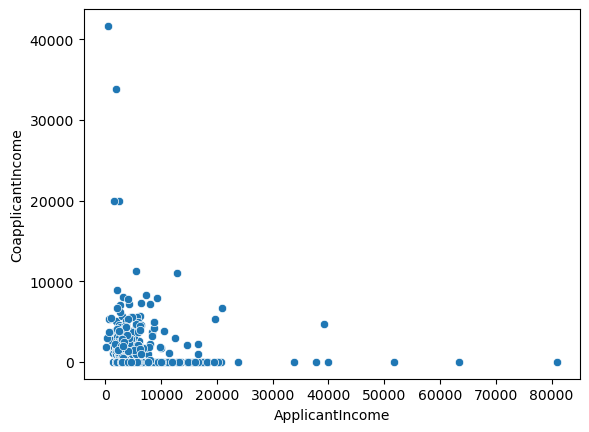

In [42]:
import seaborn as sns
sns.scatterplot(data=df, x='ApplicantIncome', y='CoapplicantIncome')


Redundancy Check — ApplicantIncome & CoapplicantIncome

Correlation = –0.11 (very weak)

Scatter plot shows scattered points with no clear trend
Conclusion: Both incomes vary independently. These two features are not redundant, because they represent income of two different people.

<Axes: xlabel='Loan_Amount_Term', ylabel='LoanAmount'>

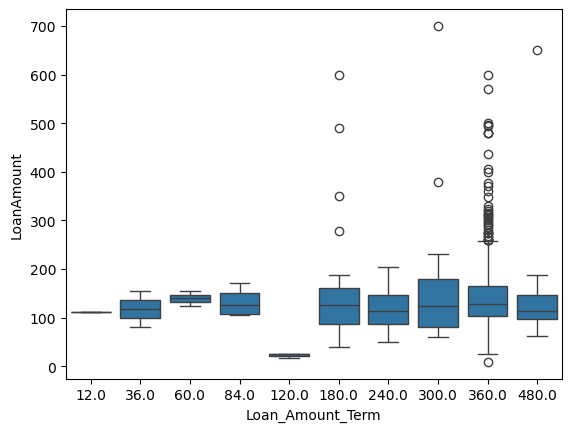

In [43]:
# 2. LoanAmount & Loan_Amount_Term — Redundancy Check
sns.boxplot(data=df, x='Loan_Amount_Term', y='LoanAmount')

In [44]:
df.groupby('Loan_Amount_Term')['LoanAmount'].mean()

Loan_Amount_Term
12.0     111.000000
36.0     117.500000
60.0     140.000000
84.0     132.250000
120.0     22.333333
180.0    146.636364
240.0    120.750000
300.0    185.153846
360.0    145.724335
480.0    151.800000
Name: LoanAmount, dtype: float64

In [45]:
import scipy.stats as stats

groups = [group["LoanAmount"].dropna() 
          for name, group in df.groupby("Loan_Amount_Term")]

stats.f_oneway(*groups)


F_onewayResult(statistic=np.float64(1.142109195119564), pvalue=np.float64(0.33051999950231353))

Redundancy Check — LoanAmount & Loan_Amount_Term

Boxplot shows overlapping distributions

Group means show no clear increasing/decreasing pattern

ANOVA p-value = 0.33 (no significant difference)
Conclusion: LoanAmount and LoanTerm do not depend on each other. They describe different aspects of a loan, so they are not redundant.

-----------------------------------------------------------------------------------------------------------

##### MULTICOLLINREARITY CHECK

In [46]:
df[num_cols].corr()

,ApplicantIncome,CoapplicantIncome,LoanAmount
ApplicantIncome,1.000000,-0.116605,0.565181
CoapplicantIncome,-0.116605,1.000000,0.189218
LoanAmount,0.565181,0.189218,1.000000


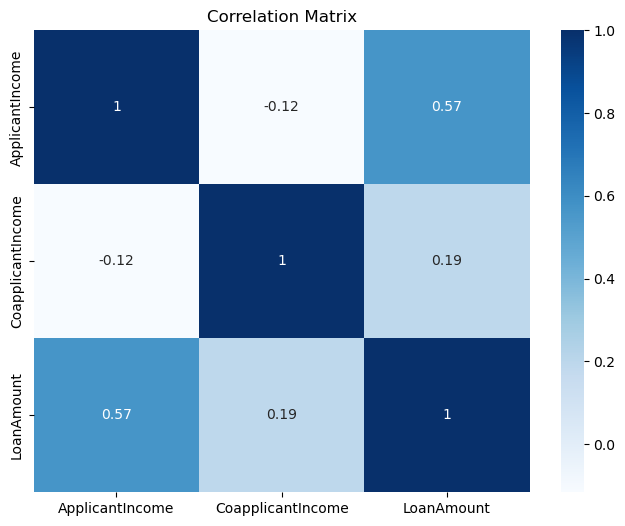

In [47]:

plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

ApplicantIncome and LoanAmount show a moderate correlation (0.56).

This means higher applicant income is somewhat associated with higher loan amount, but not very strongly.

CoapplicantIncome has a weak relationship with both ApplicantIncome and LoanAmount.

Overall, no strong correlations (>0.8) were found, so there is no multicollinearity issue among numerical features.

✔ Final Conclusion

All numerical features can be safely used for further modeling, as none of them are strongly correlated with each other.

---------------------------------------------------------------------------------------------------------

##### Feature Interaction & Combination Analysis

###### Interaction Features:
ApplicantIncome × LoanAmount
(Higher income people take bigger loans → affects approval.
Checks: Is a person with high income + high loan amount more risky than high income + low loan amount?)

LoanAmount × Loan_Amount_Term
(This shows Loan Burden = High amount + small term = high burden → less approval
Checks: Does risk change when a big loan is taken for a long term vs short term?)

Education × LoanAmount
(Educated people may take higher loans for house/business.
We are checking whether education level changes the effect of loan amount.)

Married × Dependents
(Married people naturally have more dependents.
Family size impacts loan repayment ability.)

Credit_History × Property_Area
(Urban people with good credit get more approval.
Rural people with no credit get less approval.
This combination gives strong patterns.)

###### Combination Feature
TotalIncome = ApplicantIncome + CoapplicantIncome
(combining Applicant’s and Co-applicant’s income because bank sees total earning power.)

In [48]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag,ApplicantIncome_bins,CoapplicantIncome_bins,LoanAmount_bins
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1,Urban,1,1,0,"(5185.6, 6252.4]","(-0.001, 1188.5]","(119.2, 128.0]"
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,0,0,0,"(4343.6, 5185.6]","(1188.5, 1689.6]","(119.2, 128.0]"
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,1,0,0,"(2605.4, 3050.4]","(-0.001, 1188.5]","(8.999, 72.3]"
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,1,0,0,"(2216.1, 2605.4]","(2083.0, 2535.0]","(119.2, 128.0]"
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,1,0,0,"(5185.6, 6252.4]","(-0.001, 1188.5]","(136.0, 155.0]"


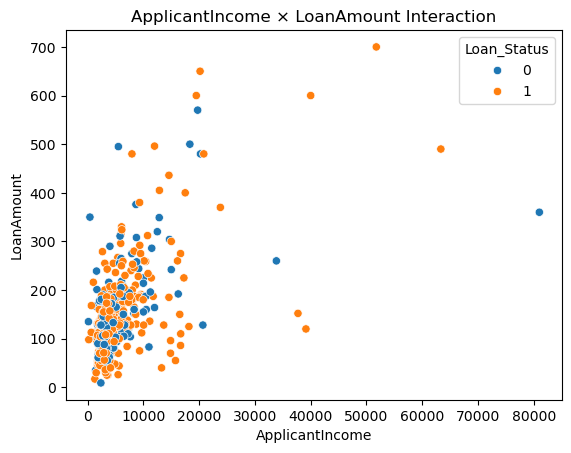

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24236\1798166409.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Income_bin")["Loan_Status"].mean()


Income_bin
Low          0.688312
Medium       0.686275
High         0.692810
Very High    0.681818
Name: Loan_Status, dtype: float64

In [49]:
#1) ApplicantIncome × LoanAmount
# Scatterplot (pattern check)
sns.scatterplot(x="ApplicantIncome", y="LoanAmount", hue="Loan_Status", data=df)
plt.title("ApplicantIncome × LoanAmount Interaction")
plt.show()

# Binning income for approval rate
df["Income_bin"] = pd.qcut(df["ApplicantIncome"], q=4, labels=["Low", "Medium", "High", "Very High"])

df.groupby("Income_bin")["Loan_Status"].mean()



Scatterplot:

The scatterplot shows no clear separation between approved and rejected applications across ApplicantIncome and LoanAmount. Approved (1) and rejected (0) points overlap heavily, indicating little interaction between these two features.

Binning approval rates:

Approval rates remain almost the same across all income bins, confirming that income does not strongly influence loan approval.

So:
No strong interaction.

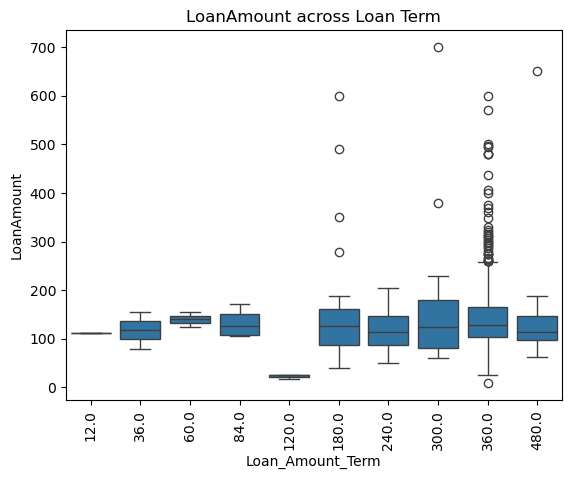

(Loan_Amount_Term
 12.0     111.000000
 36.0     117.500000
 60.0     140.000000
 84.0     132.250000
 120.0     22.333333
 180.0    146.636364
 240.0    120.750000
 300.0    185.153846
 360.0    145.724335
 480.0    151.800000
 Name: LoanAmount, dtype: float64,
 Loan_Amount_Term
 12.0     1.000000
 36.0     0.000000
 60.0     1.000000
 84.0     0.750000
 120.0    1.000000
 180.0    0.659091
 240.0    0.750000
 300.0    0.615385
 360.0    0.697719
 480.0    0.400000
 Name: Loan_Status, dtype: float64)

In [50]:
# 2) LoanAmount × Loan_Amount_Term
# Boxplot (because Loan_Amount_Term behaves categorical)
sns.boxplot(x="Loan_Amount_Term", y="LoanAmount", data=df)
plt.xticks(rotation=90)
plt.title("LoanAmount across Loan Term")
plt.show()

# Approval rate for each combination
df.groupby("Loan_Amount_Term")["LoanAmount"].mean(), \
df.groupby("Loan_Amount_Term")["Loan_Status"].mean()


Observation from Boxplot:

Longer terms (especially 360 months) have a wider spread of loan amounts.

Shorter terms usually have smaller loan amounts.

There is no smooth or consistent increasing pattern in median loan amount across terms.

Approval Rate Check:
I calculated mean Loan_Status for each Loan_Amount_Term. Approval rates vary randomly across terms. Short terms have extreme values (0% or 100%) because they occur very few times, and longer terms have approval around 65–70%.

Conclusion:
There is no strong interaction between LoanAmount and Loan_Amount_Term.
Loan term does not consistently change how loan amount affects approval.

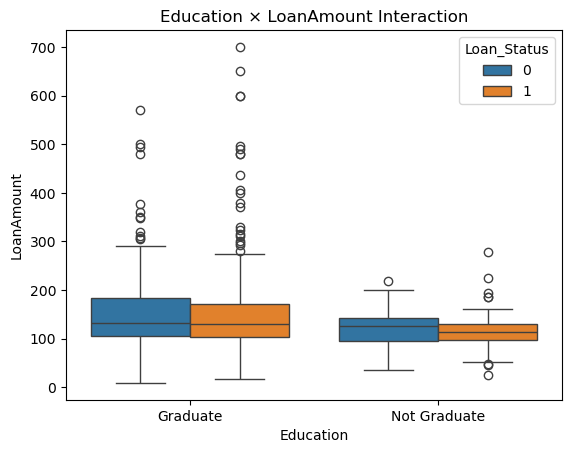

Education
Graduate        0.708333
Not Graduate    0.611940
Name: Loan_Status, dtype: float64

In [51]:
# 3) Education × LoanAmount
# Boxplot
sns.boxplot(x="Education", y="LoanAmount", hue="Loan_Status", data=df)
plt.title("Education × LoanAmount Interaction")
plt.show()

# Approval rate per category
df.groupby("Education")["Loan_Status"].mean()


I checked whether the effect of LoanAmount on Loan_Status changes for Graduates and Non-Graduates.

Graduates have a higher approval rate (70.8%) compared to Non-Graduates (61.1%).

Graduates also take slightly higher loan amounts, with a wider range.

However, the boxplot shows that approvals and rejections occur across all loan amounts for both groups.

Conclusion:
Education impacts approval rate, but LoanAmount does not change approval differently for Graduates and Non-Graduates.
Therefore, the interaction between Education and LoanAmount is weak.

In [52]:
# 4) Married × Dependents
pd.crosstab(df["Married"], df["Dependents"], normalize="index")

Dependents,0,1,2,3
Married,,,,
No,0.821596,0.107981,0.037559,0.032864
Yes,0.461347,0.197007,0.231920,0.109726


In [53]:
pd.crosstab([df["Married"], df["Dependents"]], df["Loan_Status"], normalize="index")

Loan_Status                0         1
Married Dependents                    
No      0           0.360000  0.640000
        1           0.434783  0.565217
        2           0.375000  0.625000
        3           0.428571  0.571429
Yes     0           0.270270  0.729730
        1           0.329114  0.670886
        2           0.236559  0.763441
        3           0.340909  0.659091

Married applicants usually have more dependents, while unmarried applicants mostly have zero dependents.
When we check loan approval rates for each Married × Dependents combination, we find that approval rates for unmarried applicants remain almost the same across all dependent categories.
However, for married applicants, approval rates are generally higher (around 66–76%), especially for those with 0 or 2 dependents.
Conclusion: Moderate interaction, not very strong

In [54]:
# 5) Credit_History × Property_Area
pd.crosstab(df["Credit_History"], df["Property_Area"], values=df["Loan_Status"], aggfunc="mean")

Property_Area,Rural,Semiurban,Urban
Credit_History,,,
0,0.071429,0.133333,0.032258
1,0.715232,0.862069,0.771930


The interaction between Credit History and Property Area shows a very strong pattern. Applicants with poor credit history have extremely low approval rates in every area. However, once credit history is good, approval increases sharply across all regions, with the highest approval in Semiurban areas (86%). This means credit history is the dominant factor, and property area enhances its effect. Semiurban applicants with good credit history have the best approval chances.

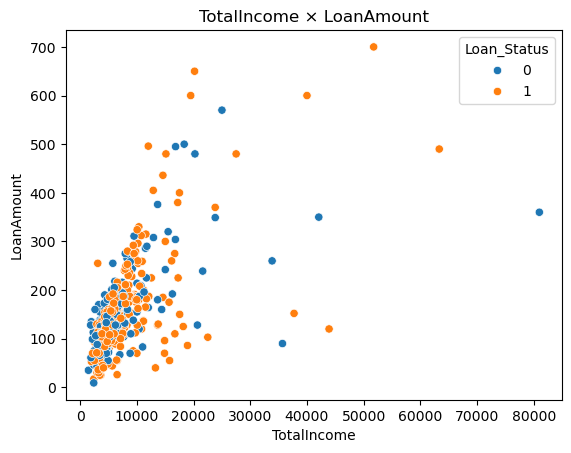

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24236\2533789321.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("TotalIncome_bin")["Loan_Status"].mean()


TotalIncome_bin
Low          0.677419
Medium       0.684211
High         0.712418
Very High    0.675325
Name: Loan_Status, dtype: float64

In [55]:
# 6) TotalIncome = ApplicantIncome + CoapplicantIncome
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

sns.scatterplot(x="TotalIncome", y="LoanAmount", hue="Loan_Status", data=df)
plt.title("TotalIncome × LoanAmount")
plt.show()

# Binning for approval relationship
df["TotalIncome_bin"] = pd.qcut(df["TotalIncome"], q=4, labels=["Low", "Medium", "High", "Very High"])
df.groupby("TotalIncome_bin")["Loan_Status"].mean()


TotalIncome was binned to check if approval varies across income levels. Approval rates stayed almost the same (67%–71%), showing income alone has weak influence.

A scatter plot of TotalIncome vs LoanAmount showed that approved and rejected cases are mixed throughout the graph, with no clear separation. This means the interaction between income and loan amount is weak and does not strongly affect loan approval.

In [56]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'LoanAmount_missing_flag', 'Loan_Amount_Term_missing_flag',
       'ApplicantIncome_bins', 'CoapplicantIncome_bins', 'LoanAmount_bins',
       'Income_bin', 'TotalIncome', 'TotalIncome_bin'],
      dtype='object')

In [57]:
cols_to_drop = [
    'ApplicantIncome_bins', 
    'CoapplicantIncome_bins', 
    'LoanAmount_bins',
    'TotalIncome', 
    'TotalIncome_bin', 
    'Income_bin'
]

df = df.drop(columns=cols_to_drop)


"All binning and helper columns created only for EDA (ApplicantIncome_bins, LoanAmount_bins, TotalIncome, etc.) were dropped.
These columns were used only for understanding patterns and are not suitable for modeling.
Final feature engineering will be done later with clean and validated features."

In [58]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1,Urban,1,1,0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,0,0,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,1,0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,1,0,0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,1,0,0


Overall Summary of Multivariate Analysis

No redundant features

No multicollinearity issues

Most interactions are weak, except:
✔ Credit_History × Property_Area, which is strong
✔ Married × Dependents, which is moderate

This completes the multivariate analysis.

-----------------------------------------------------------------------------------------------------------------

### Target Imbalance Check

Loan_Status
1    422
0    192
Name: count, dtype: int64
Loan_Status
1    68.729642
0    31.270358
Name: proportion, dtype: float64


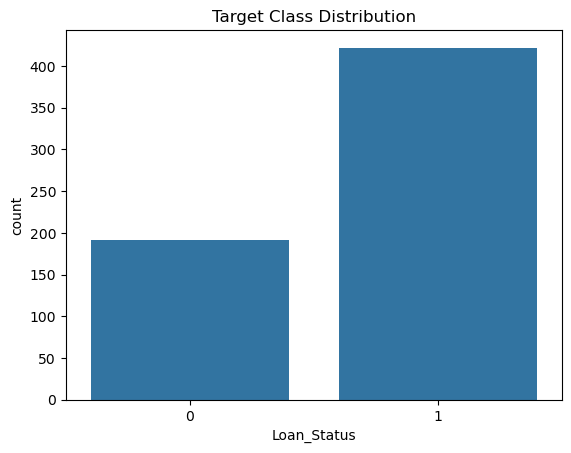

In [59]:
# Count values
print(df['Loan_Status'].value_counts())

# Percentage
print(df['Loan_Status'].value_counts(normalize=True) * 100)

# Visualization
sns.countplot(x='Loan_Status', data=df)
plt.title("Target Class Distribution")
plt.show()


The target variable Loan_Status is slightly imbalanced:

Approved (1): ~69%

Rejected (0): ~31%

This imbalance is not severe, so we can proceed without resampling.
However, evaluation metrics like Precision, Recall, and F1-score will be more reliable than accuracy.

--------------------------------------------------------------------------------------------------------------

# STEP 6 — OUTLIER DETECTION & HANDLING

In [60]:
num_cols

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

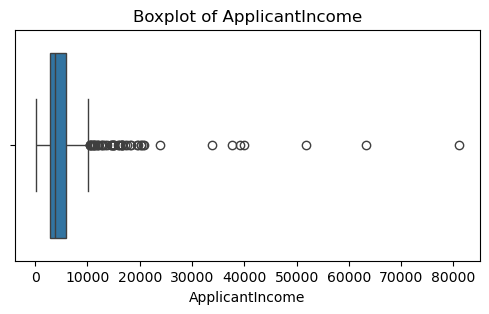

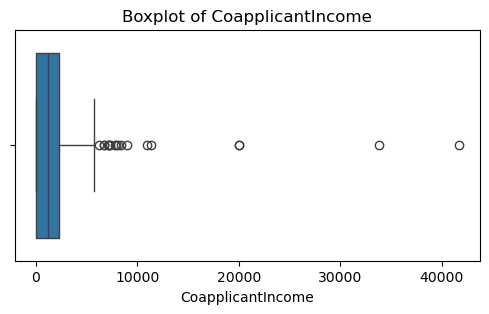

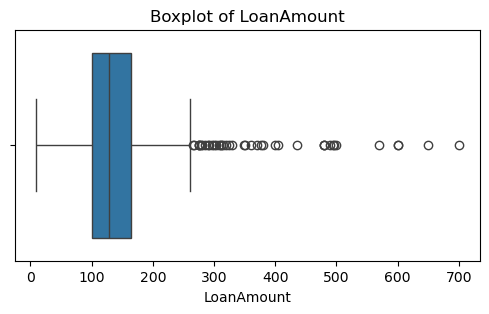

In [61]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [62]:
def find_outliers_IQR(data, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    return outliers


for col in num_cols:
    outliers = find_outliers_IQR(df, col)

    print(f"\n===== {col} =====")
    print("Total Outliers:", len(outliers))

    if len(outliers) > 0:
        print("Min Outlier:", outliers.min())
        print("Max Outlier:", outliers.max())
        print("Outlier Values:\n", outliers.values)   # shows all values
    else:
        print("No Outliers Found")



===== ApplicantIncome =====
Total Outliers: 50
Min Outlier: 10408
Max Outlier: 81000
Outlier Values:
 [12841 12500 11500 10750 13650 11417 14583 10408 23803 10513 20166 14999
 11757 14866 39999 51763 33846 39147 12000 11000 16250 14683 11146 14583
 20667 20233 15000 63337 19730 15759 81000 14880 12876 10416 37719 16692
 16525 16667 10833 18333 17263 20833 13262 17500 11250 18165 19484 16666
 16120 12000]

===== CoapplicantIncome =====
Total Outliers: 18
Min Outlier: 6250.0
Max Outlier: 41667.0
Outlier Values:
 [10968.  8106.  7210.  8980.  7750. 11300.  7250.  7101.  6250.  7873.
 20000. 20000.  8333.  6667.  6666.  7166. 33837. 41667.]

===== LoanAmount =====
Total Outliers: 41
Min Outlier: 265.0
Max Outlier: 700.0
Outlier Values:
 [267. 349. 315. 320. 286. 312. 265. 370. 650. 290. 600. 275. 700. 495.
 280. 279. 304. 330. 436. 480. 300. 376. 490. 308. 570. 380. 296. 275.
 360. 405. 500. 480. 311. 480. 400. 324. 600. 275. 292. 350. 496.]


ApplicantIncome outliers (10,408 – 81,000)

→ All are possible Indian incomes
→ Some people earn 15K, some 50K, some 80K
→ These are real, meaningful, rare, but valid
✔ Not mistakes
✔ Not noise
✔ Not to be removed

CoapplicantIncome outliers (6,250 – 41,667)

→ Also normal
→ Many households have one high earner
✔ Not mistakes
✔ Not noise
✔ Real-income variation

LoanAmount outliers (265 – 700)

→ House loans can be ₹2.5 lakh or ₹7 lakh or even 50 lakh
→ These are completely normal
✔ Not mistakes
✔ Not noise
✔ Important signals

In [63]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1,Urban,1,1,0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,0,0,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,1,0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,1,0,0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,1,0,0


In [64]:
# To handle Outliers:
import numpy as np
df['ApplicantIncome_log'] = np.log1p(df['ApplicantIncome'])
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])
df['CoapplicantIncome_log'] = np.log1p(df['CoapplicantIncome'])


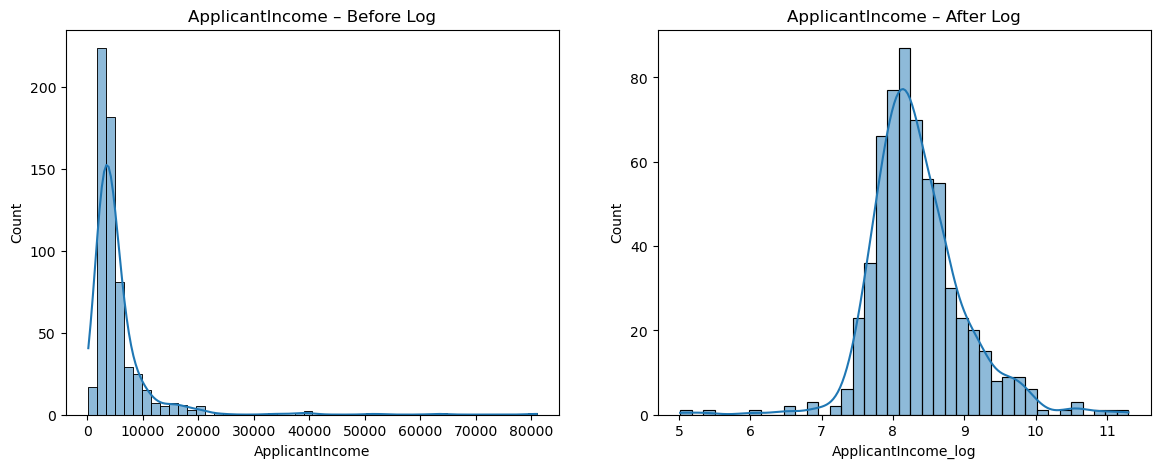

In [65]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("ApplicantIncome – Before Log")

plt.subplot(1,2,2)
sns.histplot(df['ApplicantIncome_log'], kde=True)
plt.title("ApplicantIncome – After Log")

plt.show()


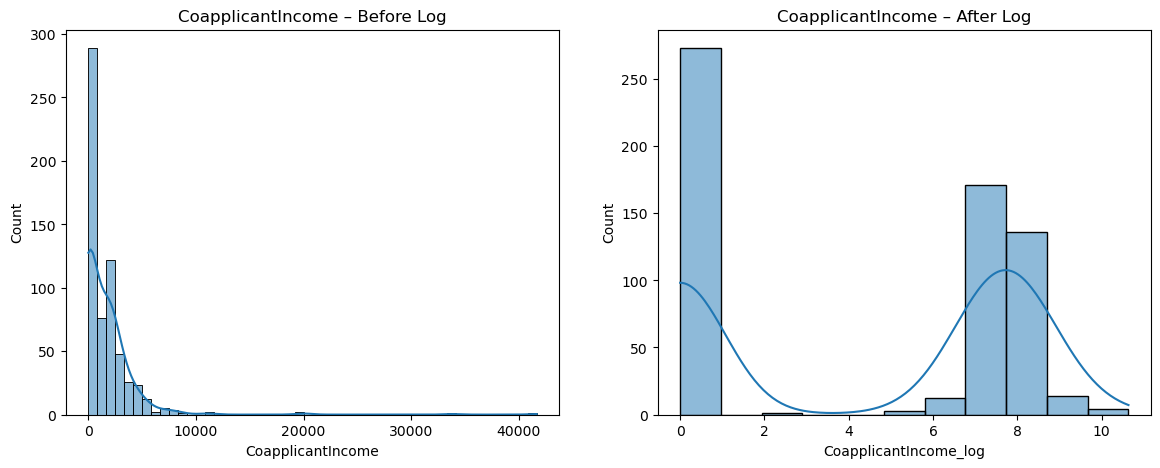

In [66]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(df['CoapplicantIncome'], kde=True)
plt.title("CoapplicantIncome – Before Log")

plt.subplot(1,2,2)
sns.histplot(df['CoapplicantIncome_log'], kde=True)
plt.title("CoapplicantIncome – After Log")

plt.show()


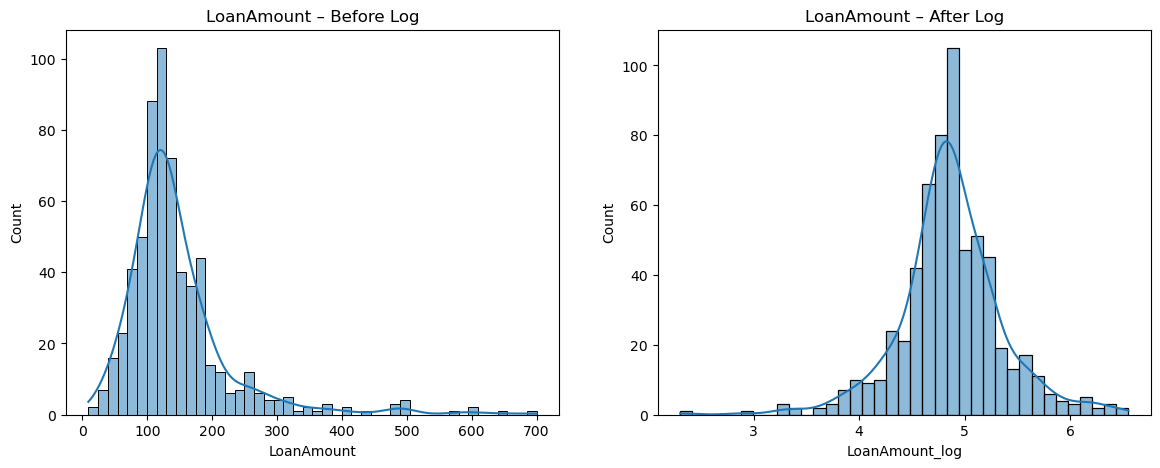

In [67]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(df['LoanAmount'], kde=True)
plt.title("LoanAmount – Before Log")

plt.subplot(1,2,2)
sns.histplot(df['LoanAmount_log'], kde=True)
plt.title("LoanAmount – After Log")

plt.show()


In [68]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1,Urban,1,1,0,8.674197,4.859812,0.000000
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,0,0,0,8.430327,4.859812,7.319202
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,1,0,0,8.006701,4.204693,0.000000
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,1,0,0,7.857094,4.795791,7.765993
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,1,0,0,8.699681,4.955827,0.000000


6.1 Univariate Outliers

I checked outliers for each numerical feature using boxplots and the IQR method.
ApplicantIncome, CoapplicantIncome, and LoanAmount had right-skewed distributions with visible outliers.

To handle this safely (without deleting useful data), I applied log transformation.
After transformation, the histograms became much more symmetrical and skewness reduced.
This helps the model learn patterns more smoothly.

Conclusion:
Univariate outliers were handled using log transformation, not deletion.

6.2 Multivariate Outliers

The dataset contains only three numerical features, and all extreme values represent genuine real-world cases (high income, large loan).
The dataset is also small, so removing multivariate outliers may remove important information.

Conclusion:
Multivariate outlier detection was not performed, because values are valid and deleting them would harm model performance.

# Step 7 — Feature Understanding

Goal of this step:

Here we judge each feature using business logic + common sense.
EDA observations are used only to support the logic.

1. Income Features (ApplicantIncome, CoapplicantIncome)

Business Logic:
Income represents repayment capacity, so it is an important factor for loan decisions.

EDA Support:
They are skewed but do not show strong approval patterns.
Still, income logically should help the model → keep these features.

2. LoanAmount

Business Logic:
Loan amount affects EMI and affordability → important for banks.

EDA Support:
Weak trend with approval but still meaningful in real life → keep.

3. Loan_Amount_Term

Business Logic:
Longer terms = smaller EMIs → banks consider this while approving.

EDA Support:
Most values are 360 months; rare terms may be grouped → keep with minor preprocessing.

4. Credit_History

Business Logic:
This is the most critical factor in real banking decisions.

EDA Support:
Clear and strongest relationship with approval → very important feature.

5. Property_Area

Business Logic:
Location affects customer profile and loan repayment behavior.

EDA Support:
Semiurban areas show higher approval → important feature.

6. Education

Business Logic:
Education level may indirectly reflect job stability and income consistency.

EDA Support:
Moderate effect on approval → useful feature.

7. Married

Business Logic:
Married applicants may have dual-income or more financial stability.

EDA Support:
Moderate positive impact → keep.

8. Dependents

Business Logic:
More dependents = higher expenses → may affect repayment ability.

EDA Support:
Weak trend individually, but strong interaction with Married → keep.

9. Gender

Business Logic:
Gender should not logically affect loan approval.

EDA Support:
Approval rates are nearly identical → not very useful, but can keep to test.

10. Self_Employed

Business Logic:
Self-employed incomes may be unstable → could affect approval.

EDA Support:
Weak relationship → optional but safe to keep.

----------------------------------------------------------------------------------------------------------------

# Step 8: Feature Engineering

In [69]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1,Urban,1,1,0,8.674197,4.859812,0.000000
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,0,0,0,8.430327,4.859812,7.319202
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,1,0,0,8.006701,4.204693,0.000000
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,1,0,0,7.857094,4.795791,7.765993
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,1,0,0,8.699681,4.955827,0.000000


In [70]:
# 1. Total Income
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

Why?
Loan approval depends on combined income, not individual incomes.

In [71]:
# 2. Income-to-Loan Ratio
df['Income_Loan_Ratio'] = df['TotalIncome'] / df['LoanAmount']

Why?
Shows repayment ability.
Higher ratio → higher approval chances.

In [72]:
# 3. EMI (Estimated Monthly Installment)
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']

Why?
Lower EMI = customer can easily afford

Higher EMI = chance of loan rejection

In [73]:
# 4. Loan-to-Income Ratio
df['Loan_to_Income'] = df['LoanAmount'] / df['TotalIncome']

Why?
If the loan amount is big but income is small → risk.
This ratio directly signals that.

In [74]:
df['Married'] = df['Married'].map({'No': 0, 'Yes': 1})

df['Property_Area'] = df['Property_Area'].map({
    'Rural': 0,
    'Semiurban': 1,
    'Urban': 2
})


In [75]:
df['Property_Area'].unique()

array([2, 0, 1])

In [76]:
# 5. Credit_History × Property_Area (Strong interaction found in EDA)
df['CH_x_Property_Area'] = df['Credit_History'] * df['Property_Area']

Why?
You found strong combined effect on approval.
So it’s useful.

In [77]:
# 6. Married × Dependents (Moderate interaction found in EDA)
df['Married_x_Dependents'] = df['Married'] * df['Dependents']

Why (simple language):

Approval chances change based on:

Married + 0 dependents

Married + 3 dependents

Single + dependents

Banks judge responsibility load, not just marital status.

This combined feature shows the family burden clearly.

In [78]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,...,Loan_Amount_Term_missing_flag,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log,TotalIncome,Income_Loan_Ratio,EMI,Loan_to_Income,CH_x_Property_Area,Married_x_Dependents
0,LP001002,Male,0,0,Graduate,No,5849,0.0,128.0,360.0,...,0,8.674197,4.859812,0.000000,5849.0,45.695312,0.355556,0.021884,2,0
1,LP001003,Male,1,1,Graduate,No,4583,1508.0,128.0,360.0,...,0,8.430327,4.859812,7.319202,6091.0,47.585938,0.355556,0.021015,0,1
2,LP001005,Male,1,0,Graduate,Yes,3000,0.0,66.0,360.0,...,0,8.006701,4.204693,0.000000,3000.0,45.454545,0.183333,0.022000,2,0
3,LP001006,Male,1,0,Not Graduate,No,2583,2358.0,120.0,360.0,...,0,7.857094,4.795791,7.765993,4941.0,41.175000,0.333333,0.024287,2,0
4,LP001008,Male,0,0,Graduate,No,6000,0.0,141.0,360.0,...,0,8.699681,4.955827,0.000000,6000.0,42.553191,0.391667,0.023500,2,0


In this step, new features were created from existing variables to improve model learning.
Based on EDA insights and domain knowledge from loan processing, the following features were engineered:

New Features:

TotalIncome: Combined income of applicant and co-applicant.

Income_Loan_Ratio: Measures repayment capacity.

EMI: Monthly installment estimate.

Loan_to_Income: Indicates burden of loan relative to income.

CH_Property_Interaction: Strong interaction found between credit history and area.

Married_Dependents: Moderate interaction improving predictive power.

------------------------------------------------------------------------------------------------------

# 9.Feature Encoding

In [79]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,...,Loan_Amount_Term_missing_flag,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log,TotalIncome,Income_Loan_Ratio,EMI,Loan_to_Income,CH_x_Property_Area,Married_x_Dependents
0,LP001002,Male,0,0,Graduate,No,5849,0.0,128.0,360.0,...,0,8.674197,4.859812,0.000000,5849.0,45.695312,0.355556,0.021884,2,0
1,LP001003,Male,1,1,Graduate,No,4583,1508.0,128.0,360.0,...,0,8.430327,4.859812,7.319202,6091.0,47.585938,0.355556,0.021015,0,1
2,LP001005,Male,1,0,Graduate,Yes,3000,0.0,66.0,360.0,...,0,8.006701,4.204693,0.000000,3000.0,45.454545,0.183333,0.022000,2,0
3,LP001006,Male,1,0,Not Graduate,No,2583,2358.0,120.0,360.0,...,0,7.857094,4.795791,7.765993,4941.0,41.175000,0.333333,0.024287,2,0
4,LP001008,Male,0,0,Graduate,No,6000,0.0,141.0,360.0,...,0,8.699681,4.955827,0.000000,6000.0,42.553191,0.391667,0.023500,2,0


In [80]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. binary categorical
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})

# 2. One-Hot Encoding (nominal categorical, NO order)
onehot_cols = ['Education', 'Property_Area']

df = pd.get_dummies(
    df,
    columns=onehot_cols,
    drop_first=True
)


In [81]:
df.head()

,Loan_ID,Gender,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,...,CoapplicantIncome_log,TotalIncome,Income_Loan_Ratio,EMI,Loan_to_Income,CH_x_Property_Area,Married_x_Dependents,Education_Not Graduate,Property_Area_1,Property_Area_2
0,LP001002,1,0,0,0,5849,0.0,128.0,360.0,1,...,0.000000,5849.0,45.695312,0.355556,0.021884,2,0,False,False,True
1,LP001003,1,1,1,0,4583,1508.0,128.0,360.0,1,...,7.319202,6091.0,47.585938,0.355556,0.021015,0,1,False,False,False
2,LP001005,1,1,0,1,3000,0.0,66.0,360.0,1,...,0.000000,3000.0,45.454545,0.183333,0.022000,2,0,False,False,True
3,LP001006,1,1,0,0,2583,2358.0,120.0,360.0,1,...,7.765993,4941.0,41.175000,0.333333,0.024287,2,0,True,False,True
4,LP001008,1,0,0,0,6000,0.0,141.0,360.0,1,...,0.000000,6000.0,42.553191,0.391667,0.023500,2,0,False,False,True


After feature encoding, all categorical columns are now converted into numeric format.

--------------------------------------------------------------------------------------------------------------

# 10. Feature Selection

In [82]:
df.head()

,Loan_ID,Gender,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,...,CoapplicantIncome_log,TotalIncome,Income_Loan_Ratio,EMI,Loan_to_Income,CH_x_Property_Area,Married_x_Dependents,Education_Not Graduate,Property_Area_1,Property_Area_2
0,LP001002,1,0,0,0,5849,0.0,128.0,360.0,1,...,0.000000,5849.0,45.695312,0.355556,0.021884,2,0,False,False,True
1,LP001003,1,1,1,0,4583,1508.0,128.0,360.0,1,...,7.319202,6091.0,47.585938,0.355556,0.021015,0,1,False,False,False
2,LP001005,1,1,0,1,3000,0.0,66.0,360.0,1,...,0.000000,3000.0,45.454545,0.183333,0.022000,2,0,False,False,True
3,LP001006,1,1,0,0,2583,2358.0,120.0,360.0,1,...,7.765993,4941.0,41.175000,0.333333,0.024287,2,0,True,False,True
4,LP001008,1,0,0,0,6000,0.0,141.0,360.0,1,...,0.000000,6000.0,42.553191,0.391667,0.023500,2,0,False,False,True


In [83]:
# STEP 0: Separate Target and Features
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

In [84]:
X.head()

,Loan_ID,Gender,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,...,CoapplicantIncome_log,TotalIncome,Income_Loan_Ratio,EMI,Loan_to_Income,CH_x_Property_Area,Married_x_Dependents,Education_Not Graduate,Property_Area_1,Property_Area_2
0,LP001002,1,0,0,0,5849,0.0,128.0,360.0,1,...,0.000000,5849.0,45.695312,0.355556,0.021884,2,0,False,False,True
1,LP001003,1,1,1,0,4583,1508.0,128.0,360.0,1,...,7.319202,6091.0,47.585938,0.355556,0.021015,0,1,False,False,False
2,LP001005,1,1,0,1,3000,0.0,66.0,360.0,1,...,0.000000,3000.0,45.454545,0.183333,0.022000,2,0,False,False,True
3,LP001006,1,1,0,0,2583,2358.0,120.0,360.0,1,...,7.765993,4941.0,41.175000,0.333333,0.024287,2,0,True,False,True
4,LP001008,1,0,0,0,6000,0.0,141.0,360.0,1,...,0.000000,6000.0,42.553191,0.391667,0.023500,2,0,False,False,True


In [85]:
y.head()

0    1
1    0
2    1
3    1
4    1
Name: Loan_Status, dtype: int64

In [86]:
# STEP 1: FILTER METHOD (LOGIC-BASED)
## What we remove:ID column,Duplicate / redundant original features
filter_drop_cols = [
    'Loan_ID',
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount'
]

X_filter = X.drop(columns=filter_drop_cols)


Original values are highly skewed.

Log version:Reduces skew,Handles outliers,Works better with ML models

In [87]:
# STEP 2: EMBEDDED METHOD (JUST OBSERVE, DO NOT DROP)
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(random_state=42)
rf.fit(X_filter, y)

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_filter.columns
).sort_values(ascending=False)

feature_importance


Credit_History                   0.196008
Income_Loan_Ratio                0.097852
Loan_to_Income                   0.097177
TotalIncome                      0.092074
ApplicantIncome_log              0.088171
EMI                              0.079278
LoanAmount_log                   0.070847
CH_x_Property_Area               0.068832
CoapplicantIncome_log            0.054540
Loan_Amount_Term                 0.021842
Dependents                       0.019307
Married_x_Dependents             0.019096
Property_Area_2                  0.017954
Property_Area_1                  0.016990
Married                          0.015390
Education_Not Graduate           0.013513
Gender                           0.011126
Self_Employed                    0.010196
LoanAmount_missing_flag          0.008450
Loan_Amount_Term_missing_flag    0.001354
dtype: float64

Credit_History is the most important feature and has a significantly higher impact on loan approval compared to other features.

Income-related features such as TotalIncome, Income_Loan_Ratio, Loan_to_Income, ApplicantIncome_log and LoanAmount_log also contribute strongly, indicating the applicant’s repayment capacity is a key decision factor.

Interaction features like Credit_History × Property_Area and Married × Dependents show moderate importance, confirming patterns observed during EDA.

Loan_Amount_Term, Dependents, and Property_Area encoded variables show lower importance, suggesting they have a limited standalone impact.

Gender, Self_Employed, missing-value flags, and education-related features have very low importance and minimal influence on the model.

In [88]:
# STEP 3: TRAIN–TEST SPLIT: Kaggle dataset already provided separate train–test Excel

In [89]:
# STEP 4: FEATURE SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_filter)

In [90]:
X_train_scaled

array([[ 0.47234264, -1.37208932, -0.73780632, ..., -0.52836225,
        -0.7820157 ,  1.42814704],
       [ 0.47234264,  0.72881553,  0.25346957, ..., -0.52836225,
        -0.7820157 , -0.70020801],
       [ 0.47234264,  0.72881553, -0.73780632, ..., -0.52836225,
        -0.7820157 ,  1.42814704],
       ...,
       [ 0.47234264,  0.72881553,  0.25346957, ..., -0.52836225,
        -0.7820157 ,  1.42814704],
       [ 0.47234264,  0.72881553,  1.24474546, ..., -0.52836225,
        -0.7820157 ,  1.42814704],
       [-2.11710719, -1.37208932, -0.73780632, ..., -0.52836225,
         1.2787467 , -0.70020801]], shape=(614, 20))

In [91]:
# STEP 5: WRAPPER METHOD (FINAL FEATURE SELECTION)
### Using RFECV with Cross-Validation
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

rfecv = RFECV(
    estimator=model,
    step=1,
    cv=5,
    scoring='roc_auc'
)

rfecv.fit(X_train_scaled, y)


,estimator,LogisticRegre...max_iter=1000)
,step,1
,min_features_to_select,1
,cv,5
,scoring,'roc_auc'
,verbose,0
,n_jobs,None
,importance_getter,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001


In [92]:
# STEP 6: FINAL SELECTED FEATURES
selected_features = X_filter.columns[rfecv.support_]
selected_features

Index(['Married', 'Credit_History', 'LoanAmount_missing_flag',
       'Loan_Amount_Term_missing_flag', 'ApplicantIncome_log',
       'LoanAmount_log', 'CoapplicantIncome_log', 'Income_Loan_Ratio',
       'Loan_to_Income', 'CH_x_Property_Area', 'Property_Area_1',
       'Property_Area_2'],
      dtype='object')

In [93]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status',
       'LoanAmount_missing_flag', 'Loan_Amount_Term_missing_flag',
       'ApplicantIncome_log', 'LoanAmount_log', 'CoapplicantIncome_log',
       'TotalIncome', 'Income_Loan_Ratio', 'EMI', 'Loan_to_Income',
       'CH_x_Property_Area', 'Married_x_Dependents', 'Education_Not Graduate',
       'Property_Area_1', 'Property_Area_2'],
      dtype='object')

In [94]:
# STEP 7: Reduce Dataset to FINAL FEATURES
X_train_final = X_filter[selected_features]

In [95]:
X_train_final

,Married,Credit_History,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log,Income_Loan_Ratio,Loan_to_Income,CH_x_Property_Area,Property_Area_1,Property_Area_2
0,0,1,1,0,8.674197,4.859812,0.000000,45.695312,0.021884,2,False,True
1,1,1,0,0,8.430327,4.859812,7.319202,47.585938,0.021015,0,False,False
2,1,1,0,0,8.006701,4.204693,0.000000,45.454545,0.022000,2,False,True
3,1,1,0,0,7.857094,4.795791,7.765993,41.175000,0.024287,2,False,True
4,0,1,0,0,8.699681,4.955827,0.000000,42.553191,0.023500,2,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,1,0,0,7.972811,4.276666,0.000000,40.845070,0.024483,0,False,False
610,1,1,0,0,8.320448,3.713572,0.000000,102.650000,0.009742,0,False,False
611,1,1,0,0,8.996280,5.537334,5.484797,32.853755,0.030438,2,False,True
612,1,1,0,0,8.933796,5.236442,0.000000,40.550802,0.024660,2,False,True


In this step, I selected the most important features using a combination of statistical, model-based, and validation-based methods.

First, I removed non-informative columns such as Loan_ID and raw income/loan columns whose transformed versions were already created.

Then, I used Random Forest feature importance to understand which features the model naturally relies on.

Finally, I applied a wrapper method (RFECV with Logistic Regression) using ROC-AUC as the evaluation metric to handle class imbalance and select the optimal subset of features.

Only features that consistently improved model performance were retained for final modeling.

-------------------------------------------------------------------------------------------------------------------

# Step 11: Train–Test Split

Since the dataset was obtained from Kaggle, a predefined train and test split was already provided.
Therefore, no additional train–test splitting was performed.
The training dataset was used for model training, while the test dataset was kept untouched for final prediction.

In [96]:
# Final selected features
X_train_final.columns

Index(['Married', 'Credit_History', 'LoanAmount_missing_flag',
       'Loan_Amount_Term_missing_flag', 'ApplicantIncome_log',
       'LoanAmount_log', 'CoapplicantIncome_log', 'Income_Loan_Ratio',
       'Loan_to_Income', 'CH_x_Property_Area', 'Property_Area_1',
       'Property_Area_2'],
      dtype='object')

In [97]:
final_features = ['Married', 'Credit_History', 'LoanAmount_missing_flag',
       'Loan_Amount_Term_missing_flag', 'ApplicantIncome_log',
       'LoanAmount_log', 'CoapplicantIncome_log', 'Income_Loan_Ratio',
       'Loan_to_Income', 'CH_x_Property_Area', 'Property_Area_1',
       'Property_Area_2']

In [98]:
# Training data
X_train = df[final_features]
y_train = df['Loan_Status']

In [99]:
X_train

,Married,Credit_History,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log,Income_Loan_Ratio,Loan_to_Income,CH_x_Property_Area,Property_Area_1,Property_Area_2
0,0,1,1,0,8.674197,4.859812,0.000000,45.695312,0.021884,2,False,True
1,1,1,0,0,8.430327,4.859812,7.319202,47.585938,0.021015,0,False,False
2,1,1,0,0,8.006701,4.204693,0.000000,45.454545,0.022000,2,False,True
3,1,1,0,0,7.857094,4.795791,7.765993,41.175000,0.024287,2,False,True
4,0,1,0,0,8.699681,4.955827,0.000000,42.553191,0.023500,2,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,1,0,0,7.972811,4.276666,0.000000,40.845070,0.024483,0,False,False
610,1,1,0,0,8.320448,3.713572,0.000000,102.650000,0.009742,0,False,False
611,1,1,0,0,8.996280,5.537334,5.484797,32.853755,0.030438,2,False,True
612,1,1,0,0,8.933796,5.236442,0.000000,40.550802,0.024660,2,False,True


In [100]:
y_train

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64

---------------------------------------------------------------------------------------------------------------

# Step 12: Feature Scaling

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

In [102]:
X_train_scaled

array([[-1.37208932,  0.41173269,  5.18739732, ...,  1.37262379,
        -0.7820157 ,  1.42814704],
       [ 0.72881553,  0.41173269, -0.1927749 , ..., -1.09528546,
        -0.7820157 , -0.70020801],
       [ 0.72881553,  0.41173269, -0.1927749 , ...,  1.37262379,
        -0.7820157 ,  1.42814704],
       ...,
       [ 0.72881553,  0.41173269, -0.1927749 , ...,  1.37262379,
        -0.7820157 ,  1.42814704],
       [ 0.72881553,  0.41173269, -0.1927749 , ...,  1.37262379,
        -0.7820157 ,  1.42814704],
       [-1.37208932, -2.42876026, -0.1927749 , ..., -1.09528546,
         1.2787467 , -0.70020801]], shape=(614, 12))

Feature scaling was performed after feature selection and before model training.
StandardScaler was used to normalize numerical features for models sensitive to feature scale, such as Logistic Regression.

# Step 13: Model Training & Baseline Evaluation

In [103]:
# Step 13A.1: Train performance (on training data)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

y_train_pred_proba = log_reg.predict_proba(X_train_scaled)[:, 1]
train_auc = roc_auc_score(y_train, y_train_pred_proba)

print("Train AUC:", train_auc)


Train AUC: 0.8036014020537123


In [104]:
y_train_pred_proba

array([0.32324734, 0.64943646, 0.69912336, 0.70437509, 0.52117177,
       0.64810011, 0.72062882, 0.06511689, 0.66914254, 0.80479156,
       0.77197282, 0.70958531, 0.67225811, 0.47801507, 0.80592995,
       0.52024573, 0.52176486, 0.01483368, 0.53381078, 0.88100269,
       0.02511099, 0.63739247, 0.07523276, 0.05628292, 0.81179746,
       0.76278138, 0.81384071, 0.74087804, 0.61491378, 0.74839911,
       0.66843917, 0.56828251, 0.44981122, 0.82983187, 0.47749782,
       0.45919823, 0.06293407, 0.80067456, 0.58515435, 0.75592745,
       0.56874489, 0.6888222 , 0.64446747, 0.82463071, 0.86026771,
       0.77236318, 0.72933816, 0.63590007, 0.02733732, 0.72917176,
       0.80517453, 0.58864061, 0.66340203, 0.61762106, 0.01558333,
       0.82577218, 0.8173217 , 0.61933485, 0.73218823, 0.70279589,
       0.71451599, 0.61768171, 0.04100669, 0.01563535, 0.03456025,
       0.78217723, 0.01641964, 0.55767776, 0.67708863, 0.03028211,
       0.66820994, 0.81169192, 0.69993444, 0.17604059, 0.79813

In [105]:
# Step 13A.2: Cross-Validation performance (Validation estimate)
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc_scores = cross_val_score(
    log_reg,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("CV AUC scores:", cv_auc_scores)
print("Mean CV AUC:", cv_auc_scores.mean())


CV AUC scores: [0.75789474 0.72848297 0.7530525  0.77503053 0.81986216]
Mean CV AUC: 0.7668645784899655


In [106]:
# Step 13A.3: Diagnose the model (MOST IMPORTANT)
# Now compare:
print("Train AUC:", train_auc)
print("Mean CV AUC:", cv_auc_scores.mean())

Train AUC: 0.8036014020537123
Mean CV AUC: 0.7668645784899655


----------------------------------------------------------------------------------------------------------------

# Step 14: Lock baseline results and move to model improvement 

In [107]:
# Increase Regularization:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=0.5
)

cv_auc = cross_val_score(
    model,
    X_train_scaled,
    y,
    cv=5,
    scoring='roc_auc'
)

print("Mean CV AUC:", cv_auc.mean())


Mean CV AUC: 0.7820686709231601


In [108]:
# Try 2–3 nearby C values
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# List of C values to TRY (regularization strength)
C_values = [0.1, 0.3, 0.5, 0.8]

results = {}

for c in C_values:
    model = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C=c
    )
    
    # 5-fold Cross Validation using ROC-AUC
    cv_scores = cross_val_score(
        model,
        X_train_scaled,
        y,
        cv=5,
        scoring='roc_auc'
    )
    
    results[c] = {
        'Mean_CV_AUC': np.mean(cv_scores),
        'Std_CV_AUC': np.std(cv_scores)
    }

# Display results
for c, score in results.items():
    print(f"C={c} → Mean CV AUC: {score['Mean_CV_AUC']:.4f}, Std: {score['Std_CV_AUC']:.4f}")


C=0.1 → Mean CV AUC: 0.7777, Std: 0.0457
C=0.3 → Mean CV AUC: 0.7805, Std: 0.0422
C=0.5 → Mean CV AUC: 0.7821, Std: 0.0398
C=0.8 → Mean CV AUC: 0.7822, Std: 0.0397


In [109]:
# Random Forest Model (Correct Way) 
###Use ONLY final selected features
X_rf = df[final_features]
y_rf = y

In [110]:
X_rf

,Married,Credit_History,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log,Income_Loan_Ratio,Loan_to_Income,CH_x_Property_Area,Property_Area_1,Property_Area_2
0,0,1,1,0,8.674197,4.859812,0.000000,45.695312,0.021884,2,False,True
1,1,1,0,0,8.430327,4.859812,7.319202,47.585938,0.021015,0,False,False
2,1,1,0,0,8.006701,4.204693,0.000000,45.454545,0.022000,2,False,True
3,1,1,0,0,7.857094,4.795791,7.765993,41.175000,0.024287,2,False,True
4,0,1,0,0,8.699681,4.955827,0.000000,42.553191,0.023500,2,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,1,0,0,7.972811,4.276666,0.000000,40.845070,0.024483,0,False,False
610,1,1,0,0,8.320448,3.713572,0.000000,102.650000,0.009742,0,False,False
611,1,1,0,0,8.996280,5.537334,5.484797,32.853755,0.030438,2,False,True
612,1,1,0,0,8.933796,5.236442,0.000000,40.550802,0.024660,2,False,True


In [111]:
y_rf

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64

In [112]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    max_depth=6,
    min_samples_leaf=20
)

cv_auc = cross_val_score(
    rf,
    X_rf,
    y_rf,
    cv=5,
    scoring='roc_auc'
)

print("Mean CV AUC:", cv_auc.mean())
print("Std CV AUC:", cv_auc.std())


Mean CV AUC: 0.7704934092395394
Std CV AUC: 0.02743400794165093


# STEP 15: Final Model Training

In [113]:
### Best model: Logistic Regression
### Best regularization: C = 0.5
### Class imbalance handled: class_weight = 'balanced'
from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=0.5,
    random_state=42
)


In [114]:
### Train on FULL training data
final_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


I first trained a Logistic Regression model and evaluated it using ROC-AUC. The train AUC was around 0.80 and cross-validation AUC was around 0.77, which is an expected gap and indicated good generalization.
I then tuned regularization using different C values. This resulted in small but consistent improvements, showing the model was already well-optimized.
I also experimented with Random Forest, but it did not significantly outperform Logistic Regression. Since the performance gains were small and Logistic Regression provided better interpretability and stability, I selected it as the final model.

-----------------------------------------------------------------------------------------------------------------

# Step 16: Final Evaluation on Test Data

In [115]:
# Load Test Data
df_test = pd.read_csv(r"C:\Users\ADMIN\Downloads\test_Y3wMUE5_7gLdaTN.csv")

In [116]:
df_test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [117]:
df_test.shape

(367, 12)

In [118]:
df_test.duplicated().sum()

np.int64(0)

In [119]:
# Save Loan_ID
test_ids = df_test['Loan_ID']

In [120]:
test_ids

0      LP001015
1      LP001022
2      LP001031
3      LP001035
4      LP001051
         ...   
362    LP002971
363    LP002975
364    LP002980
365    LP002986
366    LP002989
Name: Loan_ID, Length: 367, dtype: object

In [121]:
# Step 1: DROP columns dropped in train
df_test = df_test.drop(['Loan_ID'], axis=1)

In [122]:
df_test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [123]:
# Step 2: Handle missing values
# Handling Missing Categorical columns → mode
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']

for col in cat_cols:
    df_test[col] = df_test[col].fillna(train_modes[col])

In [124]:
#  Handling Missing Numerical columns
# Create missing indicators
df_test['LoanAmount_missing_flag'] = df_test['LoanAmount'].isnull().astype(int)
df_test['Loan_Amount_Term_missing_flag'] = df_test['Loan_Amount_Term'].isnull().astype(int)

# Now fill missing values (median)
df_test['LoanAmount'] = df_test['LoanAmount'].fillna(LoanAmount_median)
df_test['Loan_Amount_Term'] = df_test['Loan_Amount_Term'].fillna(Loan_Amount_Term_median)

In [125]:
df_test.isnull().sum()

Gender                           0
Married                          0
Dependents                       0
Education                        0
Self_Employed                    0
ApplicantIncome                  0
CoapplicantIncome                0
LoanAmount                       0
Loan_Amount_Term                 0
Credit_History                   0
Property_Area                    0
LoanAmount_missing_flag          0
Loan_Amount_Term_missing_flag    0
dtype: int64

In [126]:
df_test['Credit_History'].value_counts()

Credit_History
1.0    308
0.0     59
Name: count, dtype: int64

In [127]:
# Convert to integer
df_test['Credit_History'] = df_test['Credit_History'].astype(int)

In [128]:
# To handle Outliers:
df_test['ApplicantIncome_log'] = np.log1p(df_test['ApplicantIncome'])
df_test['LoanAmount_log'] = np.log1p(df_test['LoanAmount'])
df_test['CoapplicantIncome_log'] = np.log1p(df_test['CoapplicantIncome'])

In [129]:
df_test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log
0,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1,Urban,0,0,8.651899,4.709530,0.000000
1,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1,Urban,0,0,8.031710,4.844187,7.313887
2,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1,Urban,0,0,8.517393,5.342334,7.496097
3,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1,Urban,0,0,7.758333,4.615121,7.842671
4,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1,Urban,0,0,8.094684,4.369448,0.000000


In [130]:
# Feature Engineering columns
# 1. Total Income
df_test['TotalIncome'] = df_test['ApplicantIncome'] + df_test['CoapplicantIncome']

In [131]:
# 2. Income-to-Loan Ratio
df_test['Income_Loan_Ratio'] = df_test['TotalIncome'] / df_test['LoanAmount']

In [132]:
# 4. Loan-to-Income Ratio
df_test['Loan_to_Income'] = df_test['LoanAmount'] / df_test['TotalIncome']

In [133]:
df_test['Married'] = df_test['Married'].map({'No': 0, 'Yes': 1})

df_test['Property_Area'] = df_test['Property_Area'].map({
    'Rural': 0,
    'Semiurban': 1,
    'Urban': 2
})

In [134]:
# 5. Credit_History × Property_Area (Strong interaction found in EDA)
df_test['CH_x_Property_Area'] = df_test['Credit_History'] * df_test['Property_Area']

In [135]:
# Feature Encoding
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Label Encoding (binary categorical)
df_test['Gender'] = df_test['Gender'].map({'Male': 1, 'Female': 0})
df_test['Self_Employed'] = df_test['Self_Employed'].map({'Yes': 1, 'No': 0})


# 2. One-Hot Encoding (nominal categorical, NO order)


df_test = pd.get_dummies(
    df_test,
    columns=onehot_cols,
    drop_first=True
)


In [136]:
df_test.head()

,Gender,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,LoanAmount_missing_flag,...,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log,TotalIncome,Income_Loan_Ratio,Loan_to_Income,CH_x_Property_Area,Education_Not Graduate,Property_Area_1,Property_Area_2
0,1,1,0,0,5720,0,110.0,360.0,1,0,...,8.651899,4.709530,0.000000,5720,52.000000,0.019231,2,False,False,True
1,1,1,1,0,3076,1500,126.0,360.0,1,0,...,8.031710,4.844187,7.313887,4576,36.317460,0.027535,2,False,False,True
2,1,1,2,0,5000,1800,208.0,360.0,1,0,...,8.517393,5.342334,7.496097,6800,32.692308,0.030588,2,False,False,True
3,1,1,2,0,2340,2546,100.0,360.0,1,0,...,7.758333,4.615121,7.842671,4886,48.860000,0.020467,2,False,False,True
4,1,0,0,0,3276,0,78.0,360.0,1,0,...,8.094684,4.369448,0.000000,3276,42.000000,0.023810,2,True,False,True


In [137]:
df_test.shape

(367, 21)

In [138]:
# select final features ONLY
df_test = df_test[final_features]

In [139]:
df_test.head()

,Married,Credit_History,LoanAmount_missing_flag,Loan_Amount_Term_missing_flag,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log,Income_Loan_Ratio,Loan_to_Income,CH_x_Property_Area,Property_Area_1,Property_Area_2
0,1,1,0,0,8.651899,4.709530,0.000000,52.000000,0.019231,2,False,True
1,1,1,0,0,8.031710,4.844187,7.313887,36.317460,0.027535,2,False,True
2,1,1,0,0,8.517393,5.342334,7.496097,32.692308,0.030588,2,False,True
3,1,1,0,0,7.758333,4.615121,7.842671,48.860000,0.020467,2,False,True
4,0,1,0,0,8.094684,4.369448,0.000000,42.000000,0.023810,2,False,True


In [140]:
# scale
test_df_scaled = scaler.transform(df_test)

In [141]:
test_df_scaled

array([[ 0.72881553,  0.41173269, -0.1927749 , ...,  1.37262379,
        -0.7820157 ,  1.42814704],
       [ 0.72881553,  0.41173269, -0.1927749 , ...,  1.37262379,
        -0.7820157 ,  1.42814704],
       [ 0.72881553,  0.41173269, -0.1927749 , ...,  1.37262379,
        -0.7820157 ,  1.42814704],
       ...,
       [-1.37208932,  0.41173269, -0.1927749 , ...,  0.13866917,
         1.2787467 , -0.70020801],
       [ 0.72881553,  0.41173269, -0.1927749 , ..., -1.09528546,
        -0.7820157 , -0.70020801],
       [-1.37208932,  0.41173269, -0.1927749 , ..., -1.09528546,
        -0.7820157 , -0.70020801]], shape=(367, 12))

In [142]:
# Predict on Test Data
test_preds = final_model.predict(test_df_scaled)

In [143]:
test_preds

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,

In [144]:
# Create Submission File
submission = pd.DataFrame({
    'Loan_ID': test_ids,
    'Loan_Status': test_preds
})

In [145]:
# Save as CSV
submission.to_csv("submission.csv", index=False)

# Conclusion

In this project, I built an end-to-end loan approval prediction system using machine learning.

I performed data analysis, feature engineering, and feature selection to improve model learning and handle data imbalance.

Logistic Regression was selected as the final model based on stable cross-validated ROC-AUC performance and good generalization.

The model was evaluated on unseen test data and used to generate predictions for Kaggle submission.

In the future, model performance can be further improved using larger datasets and advanced ensemble techniques.